# 1. Instalación de librerías y configuración inicial

In [2]:
import glob
import os
import random
import tarfile
import yaml

from collections import defaultdict
import cv2
import h5py
from huggingface_hub import hf_hub_download
from IPython import display
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import scipy.io
import shutil
import tarfile
import torch
from ultralytics import YOLO, settings
import urllib.request

%matplotlib inline

In [ ]:
def set_global_seed(seed: int = 42):
    """
    Fija todas las semillas necesarias para asegurar reproducibilidad
    en experimentos.
    """
    # Python y entorno
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # CuDNN (para asegurar resultados deterministas en GPU)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Semillas fijadas en {seed}")

In [4]:
seed = 42
set_global_seed(seed)

Semillas fijadas en 42


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU disponible:", torch.cuda.is_available())
print("Nombre de la GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Ninguna")

GPU disponible: True
Nombre de la GPU: NVIDIA GeForce RTX 5060 Ti


# 2. Carga de SVHN

In [7]:
# Usar las imágenes adicionales de entrenamiento o no
USE_EXTRA = False

In [8]:
# Crear la estructura de carpetas YOLO
current_workspace = os.getcwd()
SVHN_DATA_ROOT = os.path.abspath(os.path.join(current_workspace,
                                              "..", "data",
                                              "data_modelo_reconocimiento",
                                              "svhn_yolo"))

folders = [
    os.path.join(SVHN_DATA_ROOT, "images", "train"),
    os.path.join(SVHN_DATA_ROOT, "images", "val"),
    os.path.join(SVHN_DATA_ROOT, "labels", "train"),
    os.path.join(SVHN_DATA_ROOT, "labels", "val")
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Estructura de carpetas creada.")

Estructura de carpetas creada.


In [ ]:
# Descargar y descomprimir los archivos

def process_svhn_tar(url, tar_filename, images_dest_dir, mat_final_name, prefix=""):
    """
    Descarga un archivo SVHN tar.gz desde la URL proporcionada,
    extrae las imágenes y el archivo .mat correspondiente a los directorios especificados,
    preservando la estructura de carpetas.
    """
    # Crear el directorio de destino si no existe
    os.makedirs(images_dest_dir, exist_ok=True)

    # Crear el directorio para el archivo .mat si no existe
    mat_dir = os.path.dirname(mat_final_name)
    if mat_dir:
        os.makedirs(mat_dir, exist_ok=True)

    # Descargar el archivo tar
    if not os.path.exists(tar_filename):
        print(f"  Descargando {tar_filename}...")
        urllib.request.urlretrieve(url, tar_filename)
    else:
        print(f"  {tar_filename} ya existe, omitiendo descarga.")
    
    # Extraer las imágenes
    print(f"  Extrayendo imágenes de {tar_filename}...")
    with tarfile.open(tar_filename, 'r:gz') as tar:
        for member in tar.getmembers():
            if member.isfile():
                if member.name.endswith('.png'):
                    # Cambiar el nombre del archivo si se proporciona un prefijo
                    original_name = os.path.basename(member.name)
                    new_name = f"{prefix}{original_name}" if prefix else original_name
                    dest_path = os.path.join(images_dest_dir, new_name)
                    # Extraer el archivo .png
                    with tar.extractfile(member) as source, open(dest_path, "wb") as target:  # type: ignore
                        shutil.copyfileobj(source, target)
                elif member.name.endswith('digitStruct.mat'):
                    # Extraer el archivo .mat y renombrarlo
                    with tar.extractfile(member) as source, open(mat_final_name, "wb") as target:  # type: ignore
                        shutil.copyfileobj(source, target)
    
    # Eliminar el archivo tar descargado
    print(f"  Eliminando {tar_filename}...")
    os.remove(tar_filename)

# Imágenes para el entrenamiento
print("Procesando 'train'...")
process_svhn_tar(
    url="http://ufldl.stanford.edu/housenumbers/train.tar.gz",
    tar_filename=f"{SVHN_DATA_ROOT}/train.tar.gz",
    images_dest_dir=f"{SVHN_DATA_ROOT}/images/train",
    mat_final_name=f"{SVHN_DATA_ROOT}/train.mat"
)
print("Procesamiento de 'train' completado.\n")

if USE_EXTRA:
    # Imágenes adicionales para el entrenamiento
    print("Procesando 'extra'...")
    process_svhn_tar(
        url="http://ufldl.stanford.edu/housenumbers/extra.tar.gz",
        tar_filename=f"{SVHN_DATA_ROOT}/extra.tar.gz",
        images_dest_dir=f"{SVHN_DATA_ROOT}/images/train",
        mat_final_name=f"{SVHN_DATA_ROOT}/extra.mat",
        prefix="extra_"
    )
    print("Procesamiento de 'extra' completado.\n")

# Imágenes para la validación
process_svhn_tar(
    url="http://ufldl.stanford.edu/housenumbers/test.tar.gz",
    tar_filename=f"{SVHN_DATA_ROOT}/test.tar.gz",
    images_dest_dir=f"{SVHN_DATA_ROOT}/images/val",
    mat_final_name=f"{SVHN_DATA_ROOT}/test.mat"
)
print("Procesamiento de 'test' completado.\n")

print("\nDescompresión completada.")

Procesando 'train'...
  Descargando ../data/data_modelo_reconocimiento/svhn_yolo/train.tar.gz...
  Extrayendo imágenes de ../data/data_modelo_reconocimiento/svhn_yolo/train.tar.gz...
  Eliminando ../data/data_modelo_reconocimiento/svhn_yolo/train.tar.gz...
Procesamiento de 'train' completado.

  Descargando ../data/data_modelo_reconocimiento/svhn_yolo/test.tar.gz...
  Extrayendo imágenes de ../data/data_modelo_reconocimiento/svhn_yolo/test.tar.gz...
  Eliminando ../data/data_modelo_reconocimiento/svhn_yolo/test.tar.gz...
Procesamiento de 'test' completado.


Descompresión completada.


In [9]:
# Verificar la cantidad de imágenes
train_dir = os.path.join(SVHN_DATA_ROOT, "images", "train")
val_dir = os.path.join(SVHN_DATA_ROOT, "images", "val")

num_train = len(os.listdir(train_dir)) if os.path.exists(train_dir) else 0
num_val = len(os.listdir(val_dir)) if os.path.exists(val_dir) else 0

print(f"Imágenes de Train: {num_train}")
print(f"Imágenes de Val: {num_val}")

Imágenes de Train: 33402
Imágenes de Val: 13068


In [ ]:
def get_bbox_data(file, f):
    """
    Extrae los atributos de cada bounding box
    del archivo digitStruct.mat
    """
    attrs = ['height', 'left', 'top', 'width', 'label']
    bbox = {}
    for key in attrs:
        attr = file[key]
        if len(attr) > 1:
            values = []
            for i in range(len(attr)):
                ref = attr[i].item()
                values.append(f[ref][()][0][0])
            bbox[key] = values
        else:
            bbox[key] = [attr[0][0]]
    return bbox

def convert_svhn_to_yolo(mat_path, output_dir, images_dir, prefix=''):
    """
    Convierte anotaciones SVHN .mat al formato YOLO:
    <class> <x_center> <y_center> <width> <height>
    """
    os.makedirs(output_dir, exist_ok=True)
    with h5py.File(mat_path, 'r') as f:
        names = f['/digitStruct/name']
        bboxes = f['/digitStruct/bbox']
        for i in range(len(names)):  # type: ignore
            # Nombre de imagen
            name_ref = names[i][0]  # type: ignore
            name = ''.join([chr(c[0]) for c in f[name_ref][()]])  # type: ignore
            prefixed_name = f"{prefix}{name}"

            # Bounding boxes
            bbox_data = get_bbox_data(f[bboxes[i][0]], f)  # type: ignore

            img_path = os.path.join(images_dir, prefixed_name)
            try:
                img = Image.open(img_path)
            except FileNotFoundError:
                print(f"Advertencia: No se encontró "
                      f"la imagen {img_path}. Saltando.")
                continue
            w, h = img.size

            yolo_lines = []
            for left, top, width, height, label in zip(
                bbox_data['left'], bbox_data['top'],
                bbox_data['width'], bbox_data['height'],
                bbox_data['label']
            ):
                label = int(label)
                if label == 10:
                    label = 0  # El dígito '0' en SVHN se guarda como 10

                left = max(0, left)
                top = max(0, top)

                x_center = (left + width / 2) / w
                y_center = (top + height / 2) / h
                norm_width = width / w
                norm_height = height / h

                # Asegurar que los valores estén entre 0 y 1
                x_center = min(max(0, x_center), 1)
                y_center = min(max(0, y_center), 1)
                norm_width = min(max(0, norm_width), 1)
                norm_height = min(max(0, norm_height), 1)

                yolo_lines.append(f"{label} {x_center} {y_center} "
                                  f"{norm_width} {norm_height}")

            txt_path = os.path.join(output_dir,
                                    prefixed_name.replace('.png', '.txt'))
            with open(txt_path, 'w') as f_out:
                f_out.write('\n'.join(yolo_lines))

    print(f"Conversión completada para {mat_path} -> {output_dir}")

In [ ]:
# Ejecutar la conversión
convert_svhn_to_yolo(
    f'{SVHN_DATA_ROOT}/train.mat',
    f'{SVHN_DATA_ROOT}/labels/train',
    f'{SVHN_DATA_ROOT}/images/train'
)
if USE_EXTRA:
    convert_svhn_to_yolo(
        f'{SVHN_DATA_ROOT}/extra.mat',
        f'{SVHN_DATA_ROOT}/labels/train',
        f'{SVHN_DATA_ROOT}/images/train',
        prefix='extra_'
    )
convert_svhn_to_yolo(
    f'{SVHN_DATA_ROOT}/test.mat',
    f'{SVHN_DATA_ROOT}/labels/val',
    f'{SVHN_DATA_ROOT}/images/val'
)

Conversión completada para ../data/data_modelo_reconocimiento/svhn_yolo/train.mat -> ../data/data_modelo_reconocimiento/svhn_yolo/labels/train
Conversión completada para ../data/data_modelo_reconocimiento/svhn_yolo/test.mat -> ../data/data_modelo_reconocimiento/svhn_yolo/labels/val


In [ ]:
absolute_data_path = os.path.abspath(SVHN_DATA_ROOT)

svhn_yaml = {
    'path': absolute_data_path,
    'train': 'images/train',
    'val': 'images/val',
    'names': {i: str(i) for i in range(10)}
}

yaml_path = os.path.join(SVHN_DATA_ROOT, 'svhn.yaml')

with open(yaml_path, 'w') as f:
    yaml.dump(svhn_yaml, f, sort_keys=False)

print(f"Archivo svhn.yaml creado en {SVHN_DATA_ROOT}/svhn.yaml")

Archivo svhn.yaml creado en ../data/data_modelo_reconocimiento/svhn_yolo/svhn.yaml


In [10]:
# Verificar la cantidad de archivos
train_img_dir = f"{SVHN_DATA_ROOT}/images/train"
train_lbl_dir = f"{SVHN_DATA_ROOT}/labels/train"
val_img_dir = f"{SVHN_DATA_ROOT}/images/val"
val_lbl_dir = f"{SVHN_DATA_ROOT}/labels/val"

num_train_img = len(os.listdir(train_img_dir)) if os.path.exists(train_img_dir) else 0
num_train_lbl = len(os.listdir(train_lbl_dir)) if os.path.exists(train_lbl_dir) else 0
num_val_img = len(os.listdir(val_img_dir)) if os.path.exists(val_img_dir) else 0
num_val_lbl = len(os.listdir(val_lbl_dir)) if os.path.exists(val_lbl_dir) else 0

print(f"Imágenes de Train: {num_train_img}")
print(f"Etiquetas de Train: {num_train_lbl}")
print(f"Imágenes de Val: {num_val_img}")
print(f"Etiquetas de Val: {num_val_lbl}")

Imágenes de Train: 33402
Etiquetas de Train: 33402
Imágenes de Val: 13068
Etiquetas de Val: 13068


# 3. Entrenamiento inicial en SVHN

Se entrena un modelo YOLOv8n desde los pesos base de yolov8n.pt sobre el dataset SVHN durante 50 épocas.

El entrenamiento inicial utiliza el programador de tasa de aprendizaje por defecto de YOLOv8, que combina una fase de _warm-up_ inicial con un descenso lineal progresivo (_linear LR decay_). Además, se utiliza _early stopping_ con paciencia de 5 épocas, para evitar el sobreajuste.

In [11]:
EPOCHS = 50
BATCH_SIZE = 32
IMG_SIZE = 640
PATIENCE = 5
SAVE_PATH = os.path.abspath(f"{SVHN_DATA_ROOT}/training_runs")
YAML_PATH = os.path.abspath(f"{SVHN_DATA_ROOT}/svhn.yaml")
BASE_MODEL = os.path.abspath(f"{SVHN_DATA_ROOT}/models/yolov8n.pt")

EXPERIMENT_NAME = 'yolov8n_svhn_new'

# Ruta al checkpoint previo
checkpoint_path = os.path.join(SAVE_PATH, EXPERIMENT_NAME, "weights", "last.pt")

In [30]:
# Si hay un checkpoint previo, reanuda el entrenamiento
# Si no hay un checkpoint, empieza el entrenamiento con una seed fija
if os.path.exists(checkpoint_path):
    print("=== REANUDANDO ENTRENAMIENTO ===")
    model = YOLO(checkpoint_path)
    resume_flag = True
else:
    print("=== INICIANDO NUEVO ENTRENAMIENTO ===")
    model = YOLO(BASE_MODEL)
    resume_flag = False

# Ejecutar el entrenamiento
model.train(
    data=YAML_PATH,
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    patience=PATIENCE,
    project=SAVE_PATH,
    name=EXPERIMENT_NAME,
    resume=resume_flag,
    seed=seed,
    workers=0
)

=== INICIANDO NUEVO ENTRENAMIENTO ===
Ultralytics 8.4.120  Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_reconocimiento\svhn_yolo\svhn.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002250C31EA80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,   

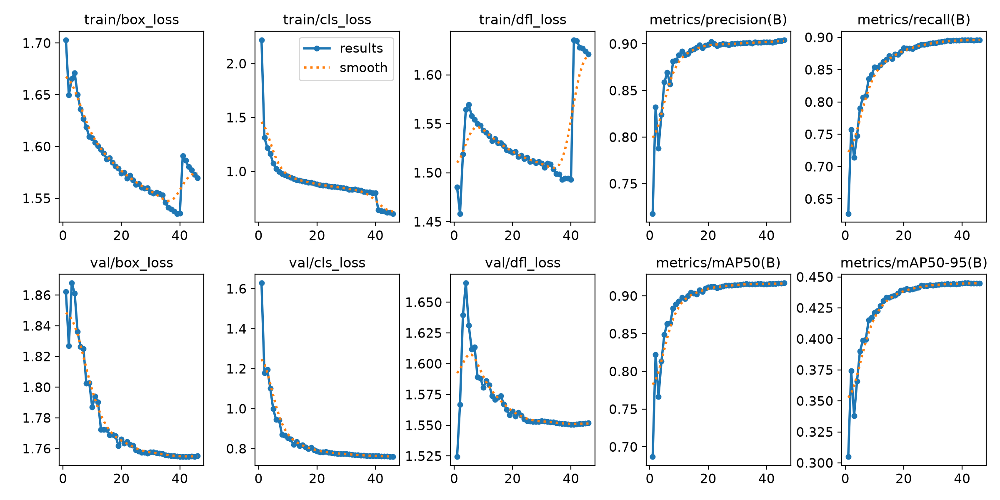

In [31]:
results_img = os.path.join(SAVE_PATH, EXPERIMENT_NAME, "results.png")
display.Image(filename=results_img)

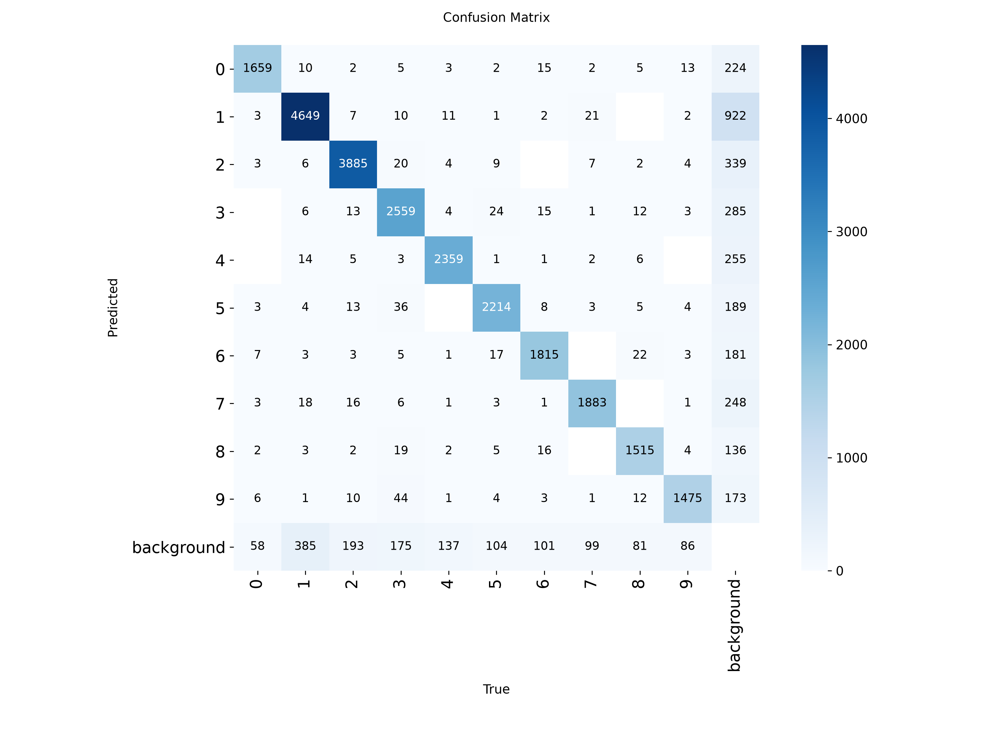

In [32]:
confusion_img = os.path.join(SAVE_PATH, EXPERIMENT_NAME, "confusion_matrix.png")
display.Image(filename=confusion_img)

Durante las primeras épocas, el modelo reduce muy rápidamente la pérdida de clasificación (cls_loss) y mejora progresivamente la localización (box_loss). Las métricas de desempeño muestran un aumento sostenido: la precisión pasa de 0.72 a 0.9, el _recall_ de 0.63 a 0.9 y el mAP50 alcanza 0.92, aproximadamente.

El mAP50-95 llega a 0.45, consistente con un modelo ligero como YOLOv8n y un _dataset_ de dígitos con condiciones de captura muy variadas.

En conjunto, el modelo aprendió representaciones robustas de los dígitos en condiciones de iluminación y fondo variables, lo que lo convierte en una base sólida para el _fine-tuning_ posterior en el _dataset_ adaptado de puntajes de evaluaciones físicas.

# 4. Carga de _dataset_ propio para _fine-tuning_

In [13]:
current_workspace = os.getcwd()
DATA_ROOT_RECOGNITION = os.path.abspath(os.path.join(current_workspace,
                                                     "..", "data",
                                                     "data_modelo_reconocimiento"))
TARGET_DIR = os.path.join(DATA_ROOT_RECOGNITION, "digits_yolo")
EXTRACTED_DATA_DIR = os.path.join(TARGET_DIR, "data")

os.makedirs(TARGET_DIR, exist_ok=True)
os.makedirs(EXTRACTED_DATA_DIR, exist_ok=True)

# Descarga de los archivos desde el dataset
repo_id = "U20212419/digits"

# Descargar data.tar
data_tar_path = hf_hub_download(repo_id=repo_id,
                                filename="data.tar",
                                repo_type="dataset")

# Descargar train.txt
train_txt_path = hf_hub_download(repo_id=repo_id,
                                 filename="train.txt",
                                 repo_type="dataset")

# Descargar data.yaml
data_yaml_path = hf_hub_download(repo_id=repo_id,
                                 filename="data.yaml",
                                 repo_type="dataset")

print("Archivos descargados exitosamente.")

# Extraer data.tar
print("\nExtrayendo data.tar en '{TARGET_DIR}'...")
with tarfile.open(data_tar_path, "r") as tar_ref:
    tar_ref.extractall(TARGET_DIR, filter="data")

print("Subcarpetas encontradas:", os.listdir(EXTRACTED_DATA_DIR))

# Cargar rutas de imágenes desde train.txt
with open(train_txt_path, "r") as f:
    image_paths = [line.strip() for line in f.readlines()]

print(f"Total de imágenes en train.txt: {len(image_paths)}")

# Cargar data.yaml
with open(data_yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)
data_yaml["path"] = EXTRACTED_DATA_DIR
data_yaml["train"] = "images/train"
data_yaml["val"] = "images/val"
data_yaml["test"] = "images/test"

print("\ndata.yaml cargado:")
print("path:", data_yaml["path"])
print("train:", data_yaml["train"])
print("val:", data_yaml["val"])
print("test:", data_yaml["test"])
print("classes:", data_yaml["names"])

# Guardar el YAML en la carpeta data
yaml_save_path = os.path.join(EXTRACTED_DATA_DIR, 'data.yaml')
with open(yaml_save_path, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

# Verificar existencia de archivos
missing = []
for p in image_paths:
    # Limpiar el prefijo de train.txt para obtener la ruta relativa correcta
    clean_p = p.replace('./data/', '').replace('data/', '')
    full_path = os.path.join(EXTRACTED_DATA_DIR, clean_p)

    if not os.path.exists(full_path):
        missing.append(full_path)

if missing:
    print(f"{len(missing)} archivos no encontrados.")
else:
    print("Todas las imágenes existen.")

Archivos descargados exitosamente.

Extrayendo data.tar en '{TARGET_DIR}'...
Subcarpetas encontradas: ['images', 'labels']
Total de imágenes en train.txt: 1110

data.yaml cargado:
path: c:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_reconocimiento\digits_yolo\data
train: images/train
val: images/val
test: images/test
classes: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: '.'}
Todas las imágenes existen.


In [14]:
# Descargar el archivo de metadata de los videos
# Se usará la columna question_amount
repo_id_videos = "U20212419/videos"

# Descargar metadata.csv
metadata_csv_path = hf_hub_download(repo_id=repo_id_videos,
                                    filename="metadata.csv",
                                    repo_type="dataset")

print("Archivo descargado:")
print("metadata.csv:", metadata_csv_path)

# Cargar el archivo a un DataFrame
df_videos = pd.read_csv(metadata_csv_path)

print("\nCSV cargado exitosamente. Primeras 5 filas:")
print(df_videos.head())

Archivo descargado:
metadata.csv: C:\Users\Flavio\.cache\huggingface\hub\datasets--U20212419--videos\snapshots\7c4f861eaabee8c23b67a66b3eb446975a61326a\metadata.csv

CSV cargado exitosamente. Primeras 5 filas:
            name                   format  size_bytes  length_seconds  width  \
0  video_001.mp4  mov,mp4,m4a,3gp,3g2,mj2  2609345289          144.92   3840   
1  video_002.mp4  mov,mp4,m4a,3gp,3g2,mj2  1085200789          165.41   1920   
2  video_003.mp4  mov,mp4,m4a,3gp,3g2,mj2  1122202727          170.98   1920   
3  video_004.mp4  mov,mp4,m4a,3gp,3g2,mj2   793332274          120.93   1920   
4  video_005.mp4  mov,mp4,m4a,3gp,3g2,mj2  1145469583          174.36   1920   

   height  avg_frame_rate  booklet_count  question_amount  
0    2160           60.03             57                4  
1    1080           60.02             58                4  
2    1080           60.01             59                4  
3    1080           60.02             53                4  
4    1080

In [15]:
def show_obb_labels(img_path, label_path, class_names):
    """
    Visualiza etiquetas en formato OBB
    (x1 y1 x2 y2 x3 y3 x4 y4).
    """
    img = cv2.imread(img_path)
    if img is None:
        print(f"No se pudo cargar {img_path}")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if not os.path.exists(label_path):
        print(f"No se encontró {label_path}")
        return

    # Escalado de fuente según tamaño de imagen
    base_ref = 720
    scale_factor = (h / base_ref) * 0.5
    font_scale = max(0.6, 1.2 * scale_factor)
    thickness = int(max(2, 2 * scale_factor))

    with open(label_path, "r") as f:
        lines = [line.strip().split() for line in f.readlines()]

    for line in lines:
        if len(line) < 9:
            continue

        cls_id = int(line[0])
        coords = list(map(float, line[1:9]))
        points = np.array(coords, dtype=np.float32).reshape(-1, 2)

        # Convertir coordenadas normalizadas a píxeles
        points[:, 0] *= w
        points[:, 1] *= h
        points = points.astype(int)

        # Dibujar polígono
        cv2.polylines(img, [points], isClosed=True,
                      color=(0, 255, 0), thickness=2)

        # Texto con clase
        label = str(class_names.get(cls_id, cls_id))
        x_text, y_text = points[2]

        # Ajuste horizontal
        x_text = x_text + (int(60 * scale_factor)
                           if cls_id == 10
                           else int(50 * scale_factor))

        # Borde negro + texto blanco
        cv2.putText(img, label, (x_text, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale,
                    (0, 0, 0), thickness + 2, cv2.LINE_AA)
        cv2.putText(img, label, (x_text, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale,
                    (255, 255, 255), thickness, cv2.LINE_AA)

    plt.figure(figsize=(18, 18))
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(img_path))
    plt.show()

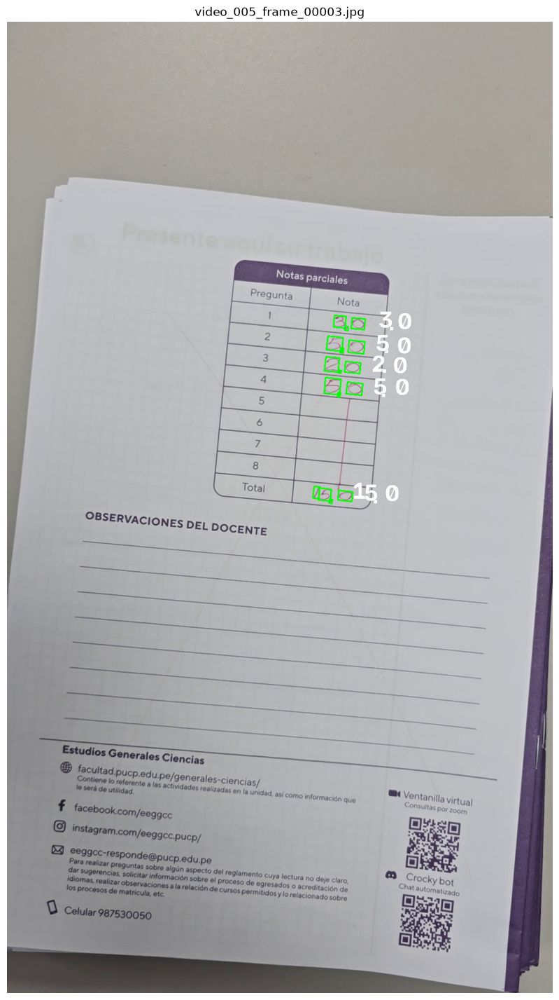

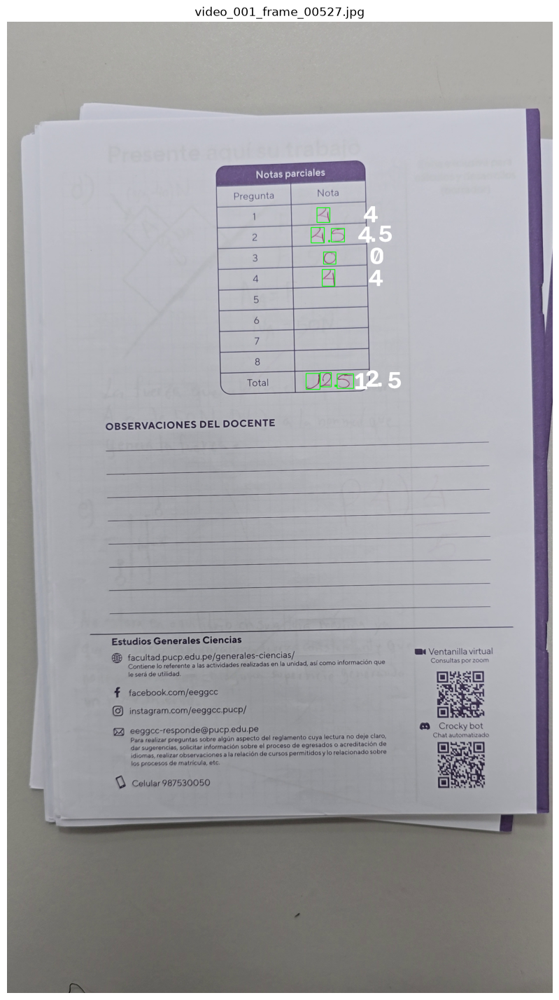

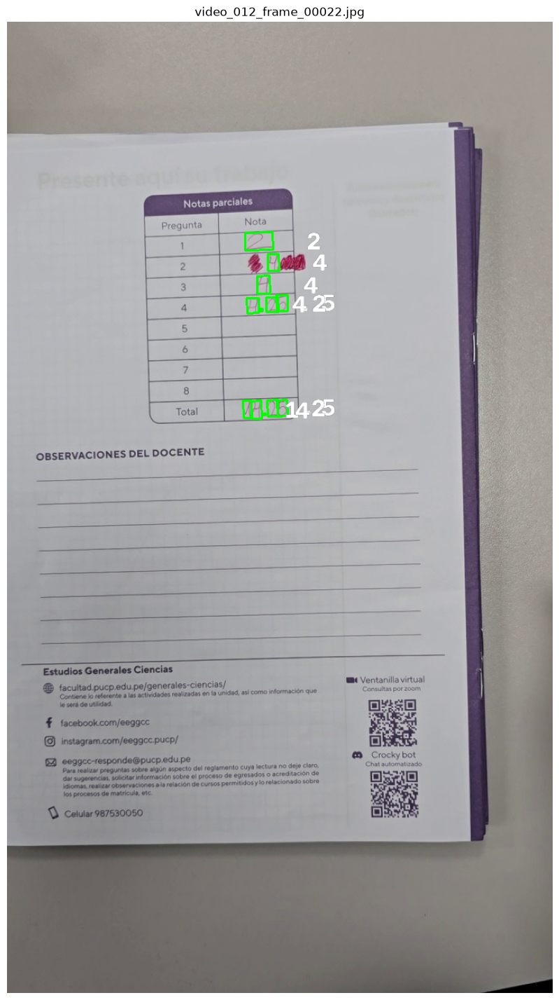

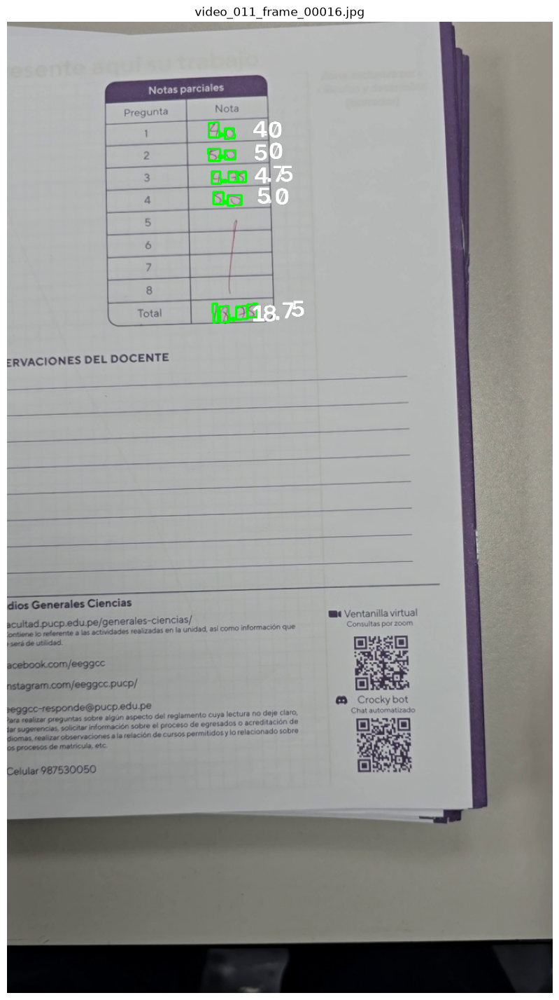

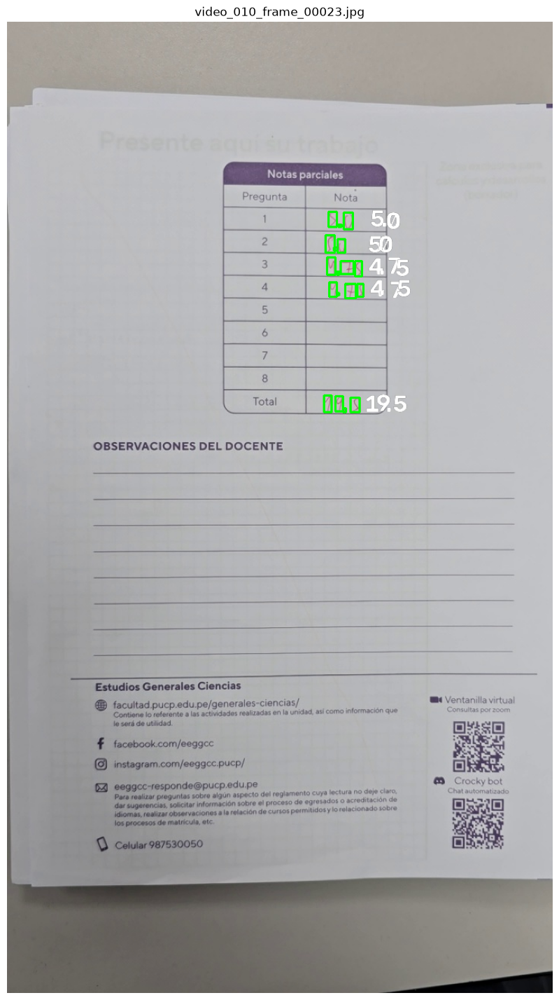

In [16]:
sample_paths = random.sample(image_paths, k=5)

for p in sample_paths:
    clean_p = p.replace('./data/', '').replace('data/', '')
    img_path = os.path.join(EXTRACTED_DATA_DIR, clean_p)
    label_path = img_path.replace("images",
                                "labels").replace(".jpg",
                                                    ".txt")
    show_obb_labels(img_path, label_path, data_yaml["names"])

Se procede a recortar la región de interés en las imágenes (el área con los puntajes).

In [17]:
def recortar_tabla(image_path, label_path, out_img_dir,
                   out_lbl_dir, min_area_ratio=0.05):
    """
    Detecta la tabla, aplica corrección de perspectiva, recorta la
    mitad derecha completa y ajusta todos los labels YOLO (formato OBB)
    para que sean relativos a este único recorte.

    Args:
        image_path (str): Ruta a la imagen original.
        label_path (str): Ruta al label OBB original.
        out_img_dir (str): Carpeta para guardar la imagen recortada.
        out_lbl_dir (str): Carpeta para guardar el label ajustado.
        min_area_ratio (float): Área mínima del contorno (relativa al
                                tamaño de la imagen) para ser considerada
                                una tabla.
    Returns:
        (str, str): Tupla con (out_img_path, out_lbl_path) o (None, None)
    """
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)

    img = cv2.imread(image_path)
    if img is None:
        print(f"No se pudo leer la imagen: {image_path}")
        return None, None

    h, w = img.shape[:2]

    # Preprocesamiento para encontrar la tabla
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(blur, 255,
                                   cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 11, 2)

    contours, _ = cv2.findContours(thresh,
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    # Usar un área mínima relativa para manejar diferentes resoluciones
    min_area = (h * w) * min_area_ratio

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue  # Contorno demasiado pequeño

        # Aplicar corrección de perspectiva (warping)
        rect = cv2.minAreaRect(cnt)
        box = np.intp(cv2.boxPoints(rect))

        def ordenar_puntos(pts):
            rect = np.zeros((4, 2), dtype="float32")
            s = pts.sum(axis=1)
            rect[0] = pts[np.argmin(s)]
            rect[2] = pts[np.argmax(s)]
            diff = np.diff(pts, axis=1)
            rect[1] = pts[np.argmin(diff)]
            rect[3] = pts[np.argmax(diff)]
            return rect

        pts = ordenar_puntos(box)
        (tl, tr, br, bl) = pts

        tabla_width = int(max(np.linalg.norm(br - bl),
                              np.linalg.norm(tr - tl)))
        tabla_height = int(max(np.linalg.norm(tr - br),
                               np.linalg.norm(tl - bl)))

        dst = np.array([
            [0, 0], [tabla_width - 1, 0],
            [tabla_width - 1, tabla_height - 1], [0, tabla_height - 1]
        ], dtype="float32")

        M = cv2.getPerspectiveTransform(pts, dst)
        tabla_warped = cv2.warpPerspective(img, M, (tabla_width,
                                                    tabla_height))

        # Recortar la mitad derecha completa
        x_offset = tabla_width // 2
        y_top = 0  # Desde el inicio vertical

        # El recorte va desde y=0 hasta el final
        # y desde x=mitad hasta el final
        crop_final = tabla_warped[y_top:tabla_height,
                                  x_offset:tabla_width]

        crop_h, crop_w = crop_final.shape[:2]

        if crop_h == 0 or crop_w == 0:
            print(f"Recorte inválido (dimensión 0) para {image_path}")
            continue

        # Ajustar los labels para este único recorte
        new_lines = []
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                # Verifica el formato "class x1 y1 x2 y2 x3 y3 x4 y4"
                if len(parts) < 9:
                    continue

                cls = parts[0]
                coords = np.array(list(map(float,
                                           parts[1:9]))).reshape(-1, 2)

                # Desnormalizar (relativo a la imagen original)
                coords[:, 0] *= w
                coords[:, 1] *= h

                # Aplicar transformación de perspectiva a los 4 puntos
                coords_h = np.concatenate([coords,
                                           np.ones((4, 1))], axis=1)
                coords_warped = (M @ coords_h.T).T
                coords_warped /= coords_warped[:, 2:3]
                coords_warped = coords_warped[:, :2]

                # Ajustar por el recorte (restar offset X, Y es 0)
                coords_warped[:, 0] -= x_offset
                coords_warped[:, 1] -= y_top

                # Filtrar BBoxes que están completamente fuera del recorte
                if ((coords_warped[:, 0] < 0).all() or
                    (coords_warped[:, 0] > crop_w).all() or
                    (coords_warped[:, 1] < 0).all() or
                    (coords_warped[:, 1] > crop_h).all()):
                    continue

                # Hacer "clipping" (traer puntos al borde si se salen)
                coords_warped[:, 0] = np.clip(coords_warped[:, 0],
                                              0, crop_w - 1)
                coords_warped[:, 1] = np.clip(coords_warped[:, 1],
                                              0, crop_h - 1)

                # Recalcular el bounding box (formato de 4 puntos)
                x_min, y_min = coords_warped.min(axis=0)
                x_max, y_max = coords_warped.max(axis=0)

                # Verificar si el área es válida después del clipping
                if (x_max - x_min) > 2 and (y_max - y_min) > 2:
                    rect_coords = np.array([
                        [x_min, y_min], [x_max, y_min],
                        [x_max, y_max], [x_min, y_max]
                    ])

                    # Renormalizar (relativo al nuevo recorte)
                    rect_coords[:, 0] /= crop_w
                    rect_coords[:, 1] /= crop_h

                    flat_coords = " ".join([f"{x:.6f} {y:.6f}" for x,
                                            y in rect_coords])
                    new_lines.append(f"{cls} {flat_coords}\n")

        # Guardar la imagen y el label
        fname = os.path.basename(image_path)
        out_img_path = os.path.join(out_img_dir, fname)
        out_lbl_path = os.path.join(out_lbl_dir,
                                    os.path.splitext(fname)[0] + ".txt")

        cv2.imwrite(out_img_path, crop_final)

        with open(out_lbl_path, "w") as f:
            f.writelines(new_lines)

        # Devolver las rutas
        return out_img_path, out_lbl_path

    # Si el bucle 'for' termina sin encontrar un contorno válido
    return None, None

Carpeta 'labels' renombrada a 'labels_polygons' en c:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_reconocimiento\digits_yolo\data
Mostrando video_001_frame_00000.jpg


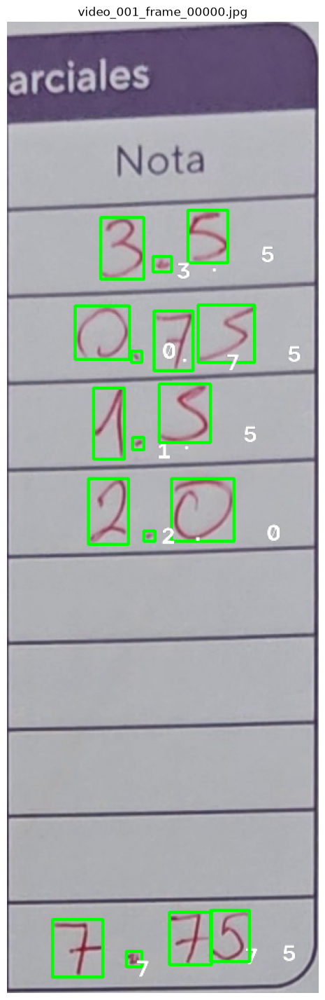

Mostrando video_002_frame_00000.jpg


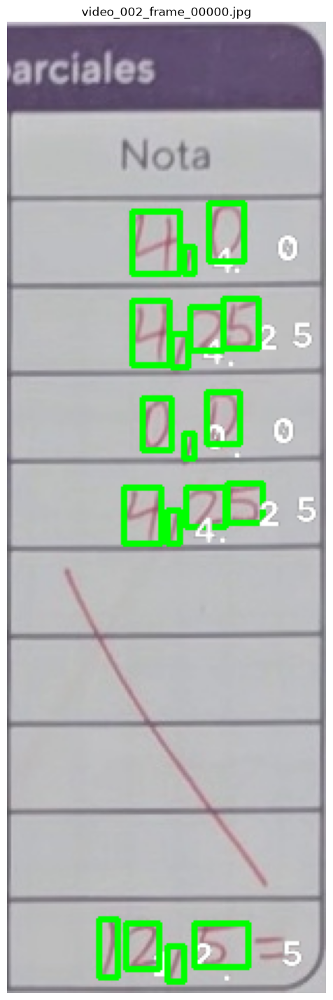

Mostrando video_003_frame_00007.jpg


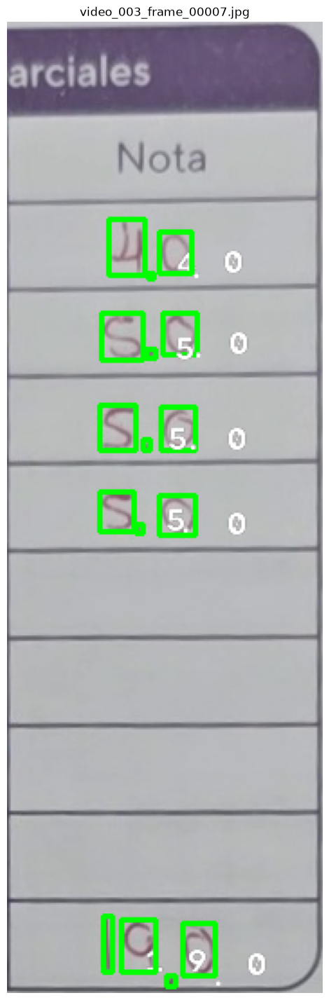

Mostrando video_004_frame_00011.jpg


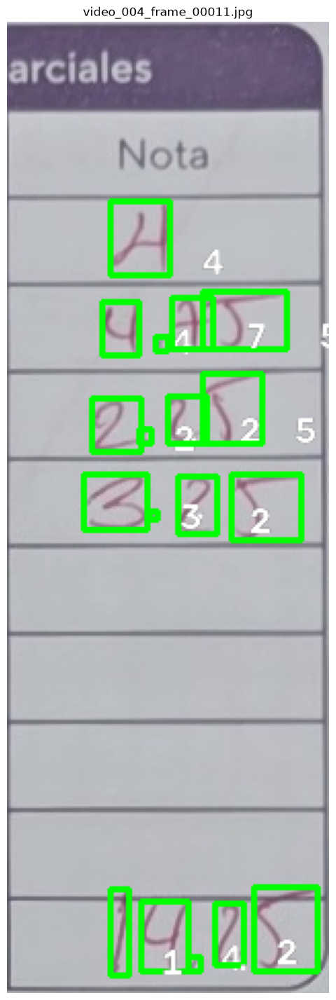

Mostrando video_005_frame_00000.jpg


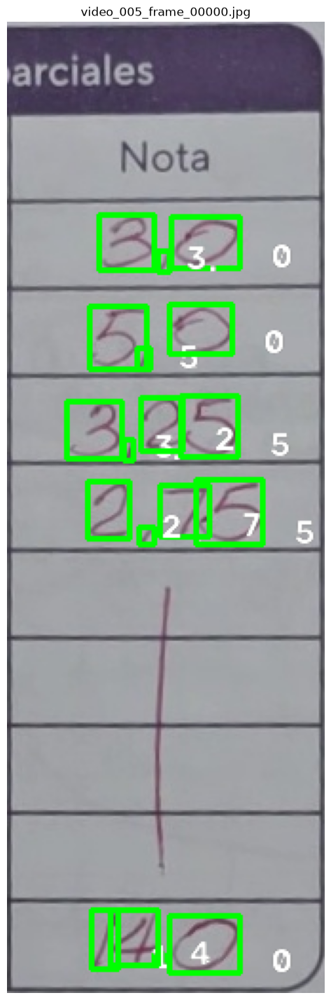

Mostrando video_006_frame_00000.jpg


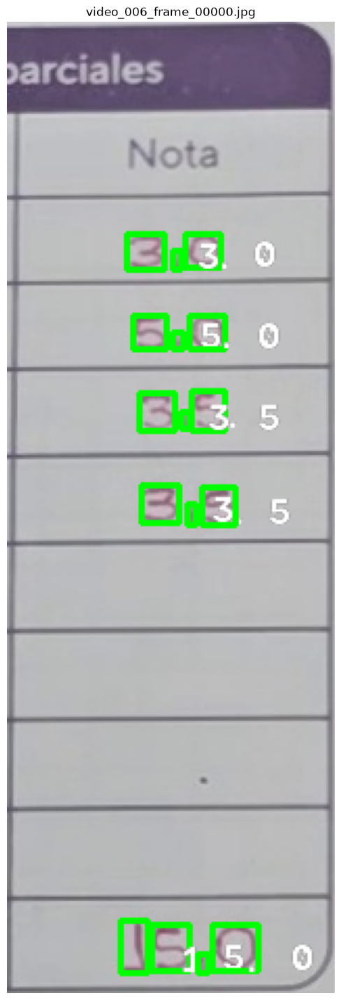

Mostrando video_007_frame_00000.jpg


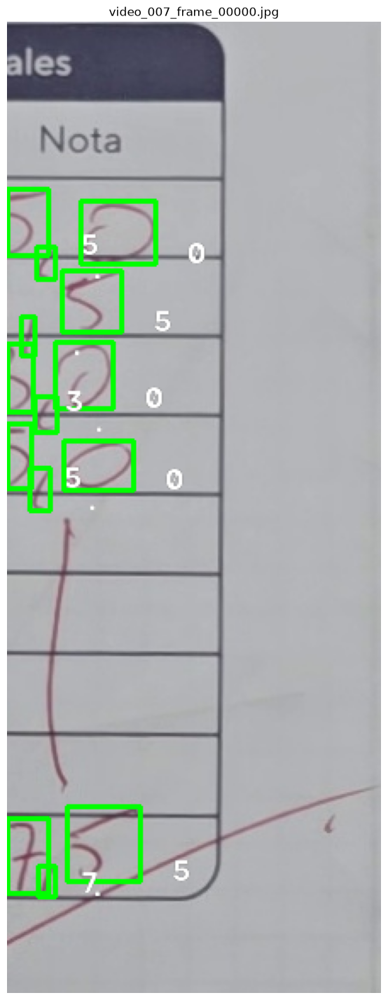

Mostrando video_009_frame_00000.jpg


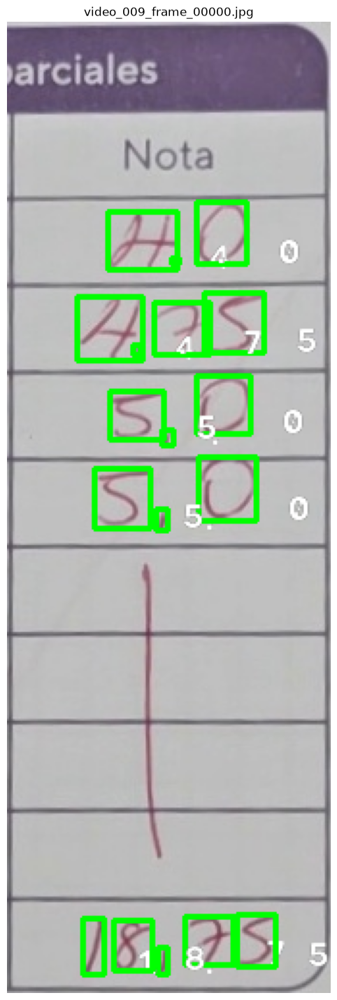

Mostrando video_010_frame_00000.jpg


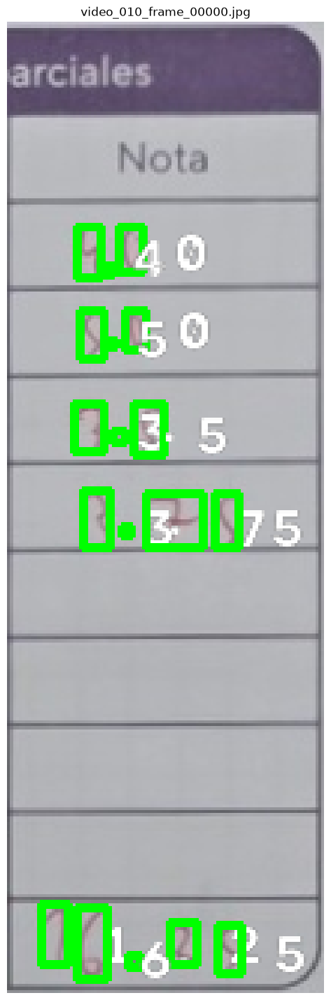

Mostrando video_011_frame_00000.jpg


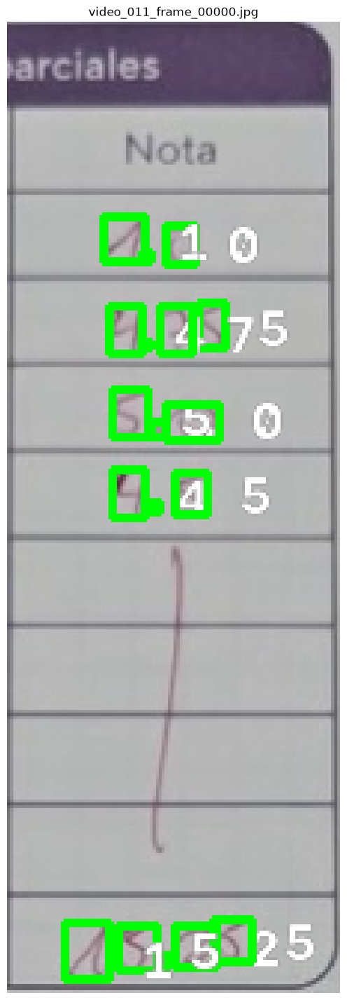

Mostrando video_012_frame_00000.jpg


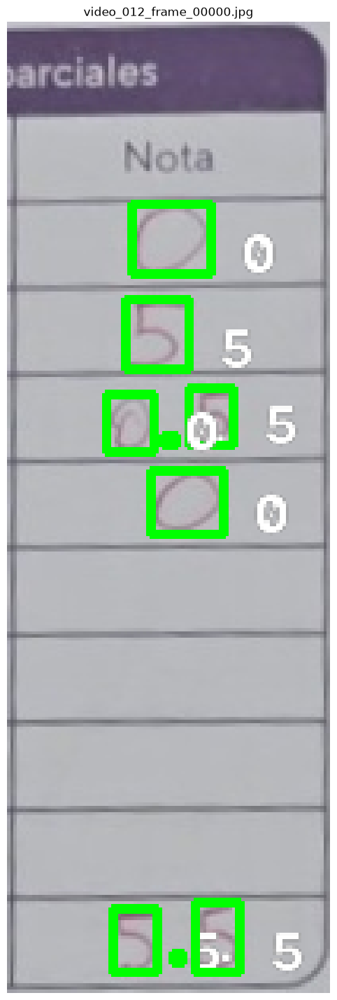

Mostrando video_013_frame_00000.jpg


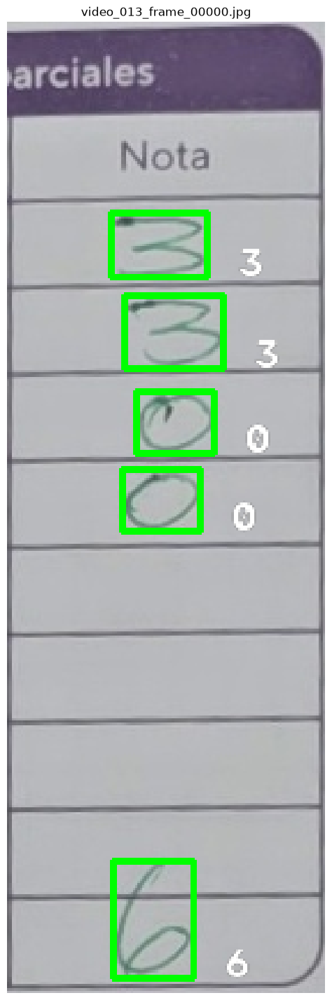

Mostrando video_014_frame_00000.jpg


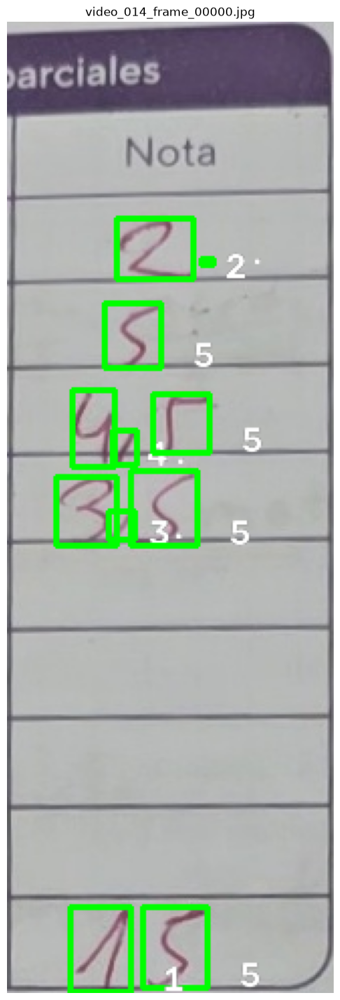

Mostrando video_015_frame_00000.jpg


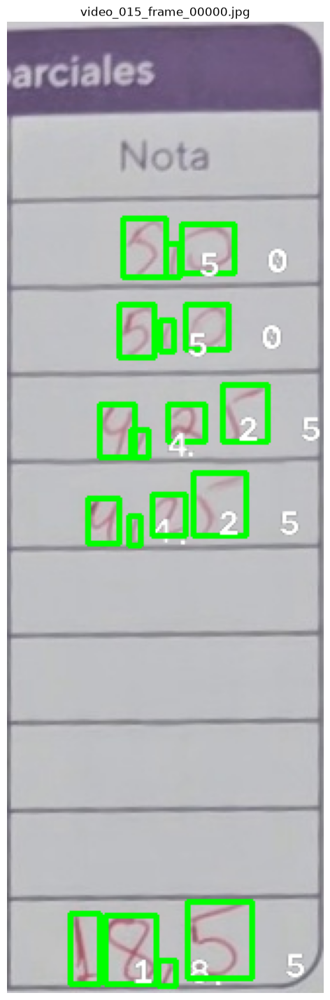

Mostrando video_016_frame_00000.jpg


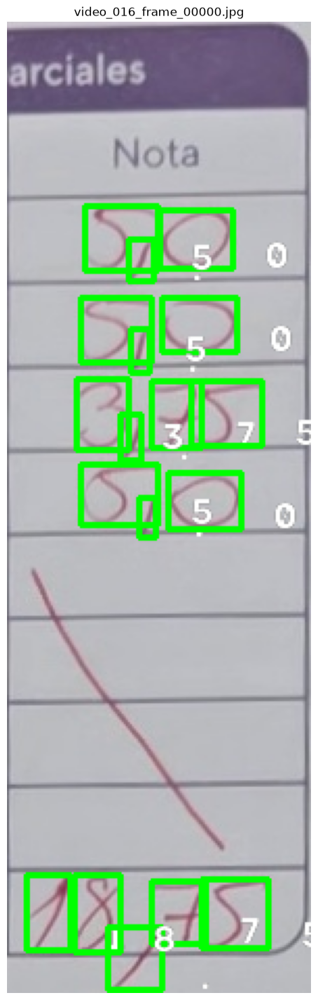

Mostrando video_017_frame_00000.jpg


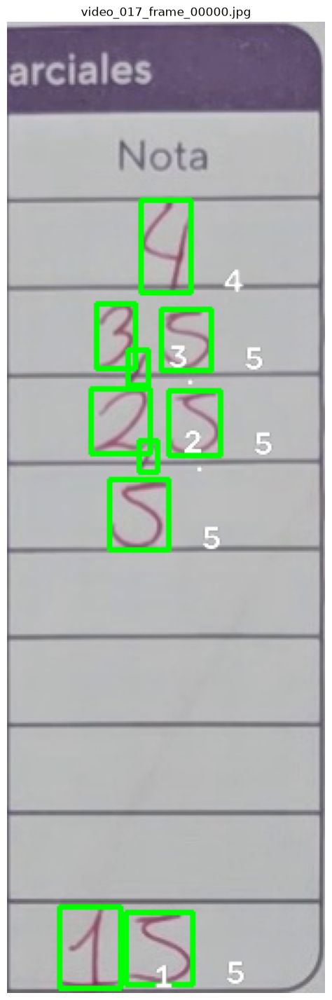

Mostrando video_018_frame_00000.jpg


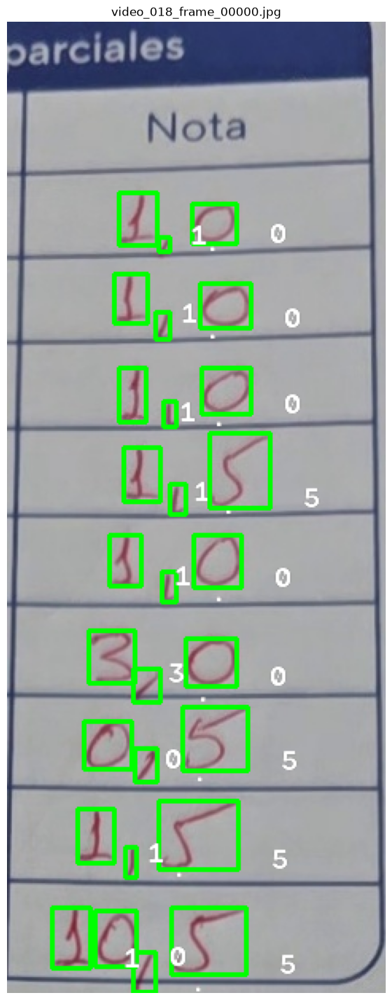

Mostrando video_019_frame_00000.jpg


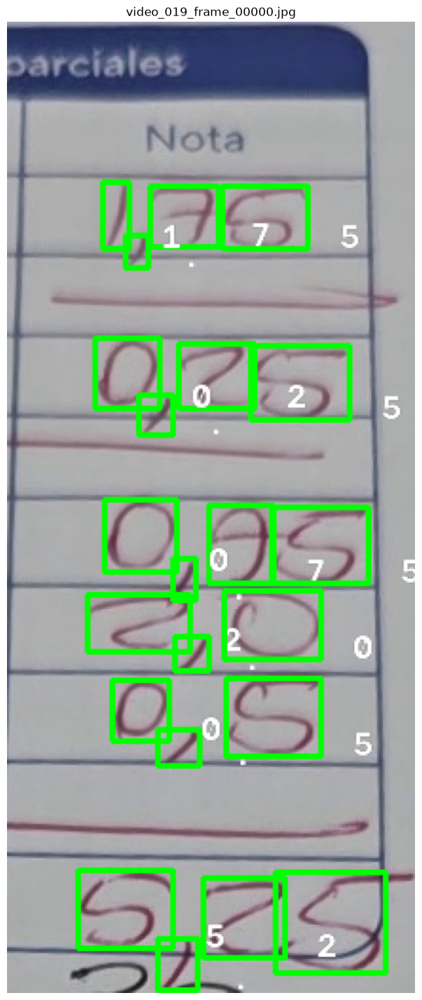

Mostrando video_022_frame_00000.jpg


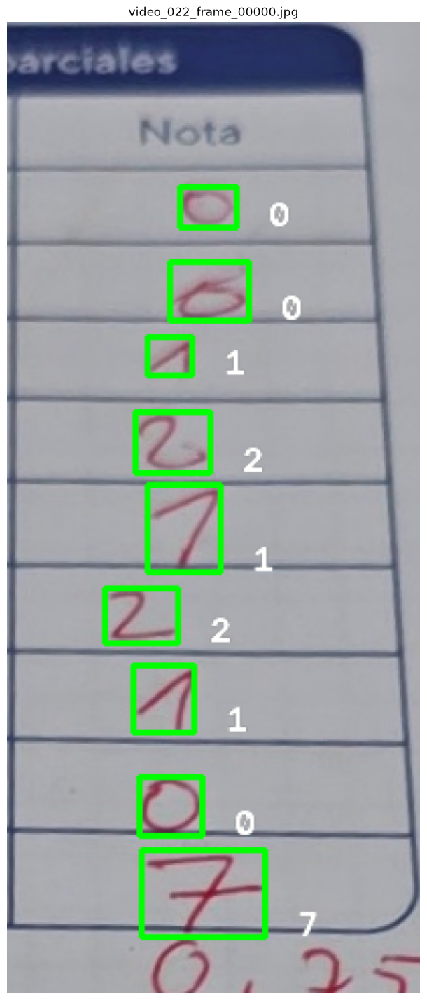

Mostrando video_028_frame_00000.jpg


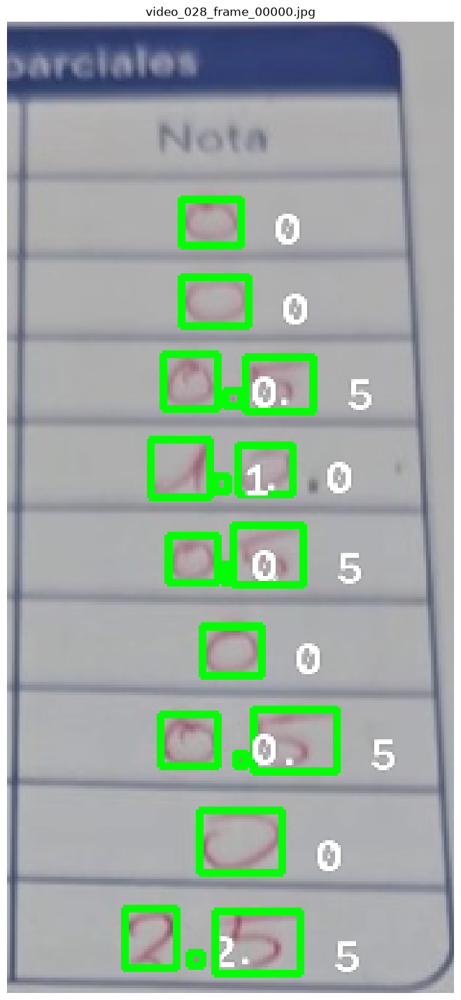

Mostrando video_032_frame_00000.jpg


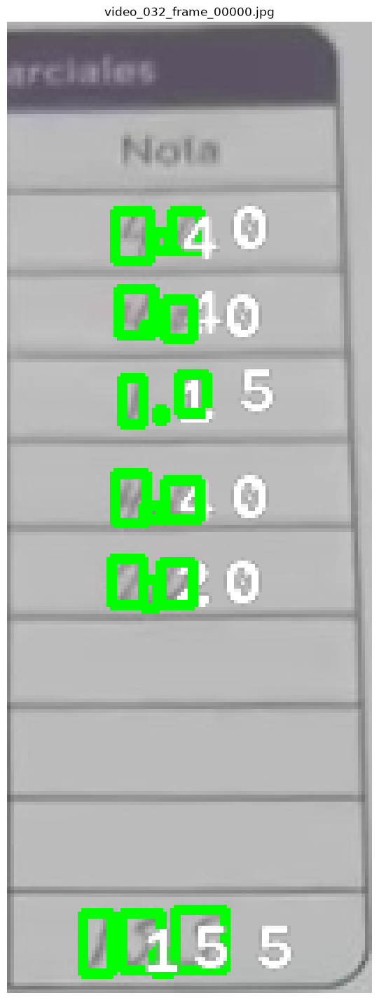

Procesamiento de recortes completado. Se mostraron muestras de 21 videos distintos.
Total de imágenes procesadas: 1110
Recortes exitosos: 1106
Recortes fallidos: 4


In [18]:
original_labels_dir = os.path.join(EXTRACTED_DATA_DIR, "labels")
polygons_labels_dir = os.path.join(EXTRACTED_DATA_DIR, "labels_polygons")

if os.path.exists(original_labels_dir) and not os.path.exists(polygons_labels_dir):
    shutil.move(original_labels_dir, polygons_labels_dir)
    print(f"Carpeta 'labels' renombrada a 'labels_polygons' en {EXTRACTED_DATA_DIR}")

# Crear una llave con el nombre del video sin la extensión
df_videos['video_key'] = df_videos['name'].str.split('.').str[0]

# Diccionario de Python para búsqueda rápida de la cantidad de preguntas
qa_mapping = pd.Series(df_videos['question_amount'].values,
                       index=df_videos['video_key']).to_dict()

# Rutas de las carpetas
input_folder = os.path.join(EXTRACTED_DATA_DIR, "images", "train")
label_folder = os.path.join(EXTRACTED_DATA_DIR, "labels_polygons", "train")
out_img_dir = os.path.join(EXTRACTED_DATA_DIR, "images_crops", "train")
out_lbl_dir = os.path.join(EXTRACTED_DATA_DIR, "labels_crops", "train")

os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_lbl_dir, exist_ok=True)

class_names = data_yaml["names"]

shown_videos = set()

total_processed = 0
successful = 0
failed = 0

for filename in os.listdir(input_folder):
    if filename.lower().endswith(".jpg"):
        total_processed += 1
        image_path = os.path.join(input_folder, filename)
        label_path = os.path.join(label_folder,
                                  os.path.splitext(filename)[0] + ".txt")

        # Recortar la mitad derecha de la tabla de puntajes
        out_img, out_lbl = recortar_tabla(
            image_path,
            label_path,
            out_img_dir,
            out_lbl_dir
        )

        # Asegurarse que el recorte fue exitoso antes de mostrarlo
        if out_img and out_lbl:
            successful += 1
            # Revisar a qué video pertenece la imagen
            current_video = None
            for vk in qa_mapping.keys():
                if filename.startswith(vk):  # type: ignore
                    current_video = vk
                    break

            # Si se encuentra el video y no se ha mostrado aún, mostrar los recortes
            if current_video and current_video not in shown_videos:
                shown_videos.add(current_video)
                print(f"Mostrando {os.path.basename(out_img)}")
                show_obb_labels(out_img, out_lbl, class_names)
        else:
            failed += 1

print("Procesamiento de recortes completado. "
      f"Se mostraron muestras de {len(shown_videos)} videos distintos.")
print(f"Total de imágenes procesadas: {total_processed}")
print(f"Recortes exitosos: {successful}")
print(f"Recortes fallidos: {failed}")

Se procede a convertir las etiquetas al formato de YOLO para detección.

Formato original: **\<class> x1 y1 x2 y2 x3 y3 x4 y4** (valores normalizados)

Formato final:  **\<class> x<sub>center</sub> y<sub>center</sub> width height** (valores normalizados)

In [19]:
def convert_obb_to_yolo(src_folder, dst_folder):
    """
    Convierte las labels del formato OBB
    <class> (x1 y1 x2 y2 x3 y3 x4 y4)
    al formato YOLO para detección
    <class> <x_center> <y_center> <width> <height>
    """
    os.makedirs(dst_folder, exist_ok=True)
    label_files = glob.glob(os.path.join(src_folder, "*.txt"))

    for label_path in label_files:
        with open(label_path, "r") as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 9:
                continue

            # Clase
            cls_id = parts[0]
            # x1 y1 x2 y2 x3 y3 x4 y4
            coords = list(map(float, parts[1:9]))
            xs = coords[0::2]
            ys = coords[1::2]

            # Bounding box (min/max)
            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)

            # Convertir a formato YOLO
            # <class> <x_center> <y_center> <width> <height>
            x_center = (x_min + x_max) / 2
            y_center = (y_min + y_max) / 2
            width = x_max - x_min
            height = y_max - y_min

            new_line = (f"{cls_id} {x_center:.6f} "
                        f"{y_center:.6f} {width:.6f} {height:.6f}\n")
            new_lines.append(new_line)

        # Guardar nueva etiqueta
        dst_path = os.path.join(dst_folder, os.path.basename(label_path))
        with open(dst_path, "w") as f:
            f.writelines(new_lines)

    print(f"Conversion completa: {len(label_files)} archivos procesados.")

In [20]:
# Convertir las labels a formato YOLO para detección
src_folder = os.path.join(EXTRACTED_DATA_DIR, "labels_crops", "train")
dst_folder = os.path.join(EXTRACTED_DATA_DIR, "labels", "train")
os.makedirs(dst_folder, exist_ok=True)

convert_obb_to_yolo(src_folder, dst_folder)

Conversion completa: 1106 archivos procesados.


In [21]:
original_train_dir = os.path.join(EXTRACTED_DATA_DIR, "images", "train")
backup_train_dir = os.path.join(EXTRACTED_DATA_DIR, "images", "train_original")
crops_train_dir = os.path.join(EXTRACTED_DATA_DIR, "images_crops", "train")

if os.path.exists(original_train_dir) and not os.path.exists(backup_train_dir):
    shutil.move(original_train_dir, backup_train_dir)
    print(f"Carpeta 'images/train' renombrada a 'images/train_original'.")
elif os.path.exists(backup_train_dir):
    print(f"Carpeta 'images/train_original' ya existe, no se renombró.")

if os.path.exists(crops_train_dir) and not os.path.exists(original_train_dir):
    shutil.move(crops_train_dir, original_train_dir)
    print(f"Imágenes recortadas movidas a 'images/train'.")
elif not os.path.exists(crops_train_dir):
    print(f"No se encontraron imágenes recortadas en 'images_crops/train'.")

Carpeta 'images/train' renombrada a 'images/train_original'.
Imágenes recortadas movidas a 'images/train'.


Se realiza el _split_ del conjunto de datos en subconjuntos de entrenamiento, validación y prueba. Se asegura todas las imágenes correspondientes a cada video original se encuentren en el mismo subconjunto, para evitar la fuga de datos, pues los fotogramas de un mismo video suelen tener características muy similares (misma escritura y condiciones de grabación).

In [22]:
base_img_dir = os.path.join(EXTRACTED_DATA_DIR, "images", "train")
base_lbl_dir = os.path.join(EXTRACTED_DATA_DIR, "labels", "train")

# Asegurar estructura de carpetas destino
for subset in ["train", "val", "test"]:
    os.makedirs(os.path.join(EXTRACTED_DATA_DIR, "images", subset), exist_ok=True)
    os.makedirs(os.path.join(EXTRACTED_DATA_DIR, "labels", subset), exist_ok=True)

# Agrupar imágenes por video para evitar fuga de datos
video_groups = defaultdict(list)
all_images = glob.glob(os.path.join(base_img_dir, "*.jpg"))

if not all_images:
    print(f"Error: No se encontraron imágenes en {base_img_dir}")
else:
    for img_path in all_images:
        img_name = os.path.basename(img_path)
        try:
            # Formato "video_ABC_...": la llave es "video_ABC"
            key_parts = img_name.split('_')
            video_key = f"{key_parts[0]}_{key_parts[1]}"
        except IndexError:
            # Si no coincide, tratarlo como un video individual
            video_key = os.path.splitext(img_name)[0]

        video_groups[video_key].append(img_path)

    print(f"Total de imágenes encontradas: {len(all_images)}")
    print(f"Agrupadas en {len(video_groups)} videos únicos.")

    # Split 70/15/15 por video
    video_keys = list(video_groups.keys())
    random.shuffle(video_keys)

    # Calcular puntos de división (70% train, 15% val, 15% test)
    n_videos = len(video_keys)
    n_train = int(n_videos * 0.70)
    n_val = int(n_videos * 0.15)
    # n_test es el resto

    # Usar np.split para manejar el 70/15/15
    # (n_train) y (n_train + n_val) son los puntos de corte
    train_video_keys, val_video_keys, test_video_keys = np.split(
        video_keys,
        [n_train, n_train + n_val]
    )

    print(f"División de videos: {len(train_video_keys)} train, "
          f"{len(val_video_keys)} val, {len(test_video_keys)} test.")

    # Crear listas de archivos para mover
    val_imgs = []
    for key in val_video_keys:
        val_imgs.extend(video_groups[key])

    test_imgs = []
    for key in test_video_keys:
        test_imgs.extend(video_groups[key])

    # Función para mover archivos
    def move_files(img_list, dest_subset, src_lbl_dir):
        """
        Mueve las imágenes y sus labels correspondientes al
        directorio del subset destino (val o test).
        """
        moved_count = 0
        for img_path in img_list:
            img_name = os.path.basename(img_path)
            lbl_name = os.path.splitext(img_name)[0] + ".txt"

            # La label siempre está en la carpeta base original
            src_lbl = os.path.join(src_lbl_dir, lbl_name)

            dst_img_path = os.path.join(EXTRACTED_DATA_DIR, "images", dest_subset, img_name)
            dst_lbl_path = os.path.join(EXTRACTED_DATA_DIR, "labels", dest_subset, lbl_name)

            # Mover imagen
            if os.path.exists(img_path):
                shutil.move(img_path, dst_img_path)
                moved_count += 1

            # Mover label
            if os.path.exists(src_lbl):
                shutil.move(src_lbl, dst_lbl_path)
            else:
                # Si la imagen ya se movió, la label podría estar en
                # la carpeta de origen original (base_lbl_dir)
                original_src_lbl = os.path.join(base_lbl_dir, lbl_name)
                if os.path.exists(original_src_lbl):
                     shutil.move(original_src_lbl, dst_lbl_path)
                else:
                    print(f"Advertencia: Label no encontrada para "
                          f"{img_name} en {src_lbl}")

        return moved_count

    # Ejecutar el movimiento
    val_moved = move_files(val_imgs, "val", base_lbl_dir)
    test_moved = move_files(test_imgs, "test", base_lbl_dir)

    n_train_final = len(all_images) - val_moved - test_moved

    # Función para contar bounding boxes
    def count_bboxes_in_dir(label_dir):
        """Lee todos los .txt en un directorio y suma sus líneas."""
        total_bboxes = 0
        # Buscar los archivos .txt en el directorio de labels
        label_files = glob.glob(os.path.join(label_dir, "*.txt"))
        for f_path in label_files:
            try:
                with open(f_path, 'r') as f:
                    # Cada línea en el archivo es un bounding box
                    total_bboxes += len(f.readlines())
            except Exception as e:
                print(f"Advertencia: No se pudo leer {f_path}: {e}")
        return total_bboxes

    # Conteo de BBoxes en las carpetas finales
    n_train_labels = count_bboxes_in_dir(os.path.join(EXTRACTED_DATA_DIR, "labels", "train"))
    n_val_labels = count_bboxes_in_dir(os.path.join(EXTRACTED_DATA_DIR, "labels", "val"))
    n_test_labels = count_bboxes_in_dir(os.path.join(EXTRACTED_DATA_DIR, "labels", "test"))

    print("\n--- Split Completado ---")
    print(f"Imágenes de Train: {n_train_final}")
    print(f"Imágenes de Val: {val_moved}")
    print(f"Imágenes de Test: {test_moved}")
    print(f"Total: {n_train_final + val_moved + test_moved}")

    print("\n--- Conteo de Bounding Boxes ---")
    print(f"BBoxes en Train: {n_train_labels}")
    print(f"BBoxes en Val: {n_val_labels}")
    print(f"BBoxes en Test: {n_test_labels}")
    print(f"Total de BBoxes: "
          f"{n_train_labels + n_val_labels + n_test_labels}")

Total de imágenes encontradas: 1106
Agrupadas en 21 videos únicos.
División de videos: 14 train, 3 val, 4 test.

--- Split Completado ---
Imágenes de Train: 701
Imágenes de Val: 172
Imágenes de Test: 233
Total: 1106

--- Conteo de Bounding Boxes ---
BBoxes en Train: 11772
BBoxes en Val: 2670
BBoxes en Test: 4273
Total de BBoxes: 18715


# 5. _Fine-tuning_

Se realiza _fine-tuning_ a partir de un modelo prentrenado, con el objetivo de adaptar sus pesos a la tarea específica de detección de dígitos en tablas de puntajes de evaluaciones de EE. GG. CC.

Dado que el conjunto de datos es reducido y presenta desbalance entre clases, se aplican técnicas de _data augmentation_ (implementación de Ultralytics YOLO) para aumentar la diversidad de ejemplos e intentar mejorar la generalización del modelo.

Se entrena durante un número fijo de 300 épocas, desactivando el _early stopping_ para garantizar que el modelo alcance la fase final de entrenamiento donde se apaga la aumentación compleja de imágenes ('close_mosaic'). Esto permite que el modelo estabilice sus pesos utilizando imágenes limpias en las últimas 30 épocas.

Aunque la desactivación del _early stopping_ incrementa teóricamente el riesgo de sobreajuste en las etapas finales del entrenamiento, este riesgo se mitiga mediante la aplicación del aumento de datos de manera agresiva y el uso de _model checkpoint_. Este último garantiza que los pesos finales utilizados correspondan a la época que maximizó las métricas en el conjunto de validación, descartando cualquier degradación posterior generada por un posible sobreajuste.

El tamaño de imagen de entrada es el doble que el del modelo inicial (escalamiento a 1280x1280 píxeles), debido a la mayor resolución promedio de las imágenes del _dataset_ propio, lo que podría ocasionar pérdida de resolución que afecte negativamente al rendimiento si se realiza el escalamiento a un tamaño muy pequeño.

In [23]:
# Parámetros de entrenamiento
BASE_MODEL_FOR_DIGITS = os.path.join(SVHN_DATA_ROOT, "training_runs", "yolov8n_svhn_new", "weights", "best.pt")
EPOCHS = 300
BATCH_SIZE = 16
IMG_SIZE = 1280
SAVE_PATH_DIGITS = os.path.join(TARGET_DIR, "training_runs")
EXPERIMENT_NAME_DIGITS = 'yolov8n_digits'
DATA_YAML = os.path.join(EXTRACTED_DATA_DIR, "data.yaml")
CONFIG_FILE_PATH = os.path.join(TARGET_DIR, "runtime_config.yaml")

# Ruta al checkpoint previo
checkpoint_path_digits = os.path.join(SAVE_PATH_DIGITS, EXPERIMENT_NAME_DIGITS, "weights", "last.pt")

# Lógica para iniciar un nuevo entrenamiento o reanudar el antiguo
if os.path.exists(checkpoint_path_digits):
    print("=== CONFIGURADO PARA REANUDAR EL ENTRENAMIENTO ===")
    model_to_use = checkpoint_path_digits
    resume_flag = True
    seed_line = ""
else:
    print("=== CONFIGURADO PARA NUEVO ENTRENAMIENTO ===")
    model_to_use = BASE_MODEL_FOR_DIGITS
    resume_flag = False
    seed_line = f"seed: {seed}"

=== CONFIGURADO PARA NUEVO ENTRENAMIENTO ===


## Optimización de hiperparámetros

Se optimizan diferentes hiperparámetros, incluyendo los de _data augmentation_, utilizando el _tuner_ propio de la librería Ultralytics YOLO.

In [24]:
# Optimización de hiperparámetros
model_tune = YOLO(BASE_MODEL_FOR_DIGITS)

search_space = {
    "lr0": (1e-6, 1e-3),
    "lrf": (0.01, 1.0),
    "momentum": (0.6, 0.98),
    "weight_decay": (1e-5, 0.01),
    "hsv_h": (0.05, 0.3),
    "hsv_s": (0.7, 0.9),
    "hsv_v": (0.4, 0.6),
    "degrees": (0.05, 10.0),
    "translate": (1e-4, 0.05),
    "scale": (0.1, 0.5),
    "shear": (1e-4, 0.15),
    "perspective": (1e-5, 5e-4),
    "mosaic": (0.0, 1.0),
    "close_mosaic": (0, 15),
    "bgr": (0.1, 0.6),
    "erasing": (0.05, 0.3),
}

TUNE_PROJECT = os.path.join(SAVE_PATH_DIGITS, "yolo_digits_tune")
TUNE_NAME = "yolo_digits_tune"

tuner_checkpoint_file = os.path.join(TUNE_PROJECT,
                                     TUNE_NAME,
                                     "tune_results.csv")

# Argumentos para el tuning de hiperparámetros
tune_args = {
    "data": DATA_YAML,
    "epochs": 100,
    "imgsz": IMG_SIZE,
    "batch": BATCH_SIZE,
    "patience": 0,
    "iterations": 10,
    "optimizer": "AdamW",
    "cos_lr": True,
    "space": search_space,
    "plots": True,
    "save": True,
    "val": True,
    "project": TUNE_PROJECT,
    "name": TUNE_NAME,
    "flipud": 0.0,
    "fliplr": 0.0,
    "mixup": 0.0,
    "cutmix": 0.0,
    "copy_paste": 0.0,
}

In [22]:
# Lógica para reanudar o iniciar un tuning de hiperparámetros nuevo
if os.path.exists(tuner_checkpoint_file):
    print(f"=== REANUDANDO SESIÓN DE TUNING en "
          f"{TUNE_PROJECT}/{TUNE_NAME} ===")
    tune_args["resume"] = True
else:
    print("=== INICIANDO NUEVA SESIÓN DE TUNING ===")
    tune_args["seed"] = seed

# Ejecutar el tuner
model_tune.tune(**tune_args)

=== INICIANDO NUEVA SESIÓN DE TUNING ===
Tuner: Initialized Tuner instance with 'tune_dir=C:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_reconocimiento\digits_yolo\training_runs\yolo_digits_tune\yolo_digits_tune'
Tuner:  Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/10 with hyperparameters: {'lr0': 0.001, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'hsv_h': 0.05, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.05, 'translate': 0.05, 'scale': 0.5, 'shear': 0.0001, 'perspective': 1e-05, 'mosaic': 1.0, 'close_mosaic': 10, 'bgr': 0.1, 'erasing': 0.3}
Saved C:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_reconocimiento\digits_yolo\training_runs\yolo_digits_tune\yolo_digits_tune\tune_scatter_plots.png
Saved C:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_reconocimiento\digits_yolo\training_runs\yolo_digits_tune\yolo_digits_tune\tune_fitness.png

Tuner: 1/10 iterations complete  (1420.75s)
Tuner: Re

In [25]:
# Archivo con los mejores hiperparámetros
best_hyperparameters_path = os.path.join(TARGET_DIR, TUNE_PROJECT, TUNE_NAME, "best_hyperparameters.yaml")
with open(best_hyperparameters_path, "r") as f:
    best_hyperparameters = yaml.safe_load(f)

print(best_hyperparameters)

{'lr0': 0.001, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'hsv_h': 0.05, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.05, 'translate': 0.05, 'scale': 0.5, 'shear': 0.0001, 'perspective': 1e-05, 'mosaic': 1.0, 'close_mosaic': 10, 'bgr': 0.1, 'erasing': 0.3}


In [26]:
best_lrf = best_hyperparameters.get("lrf", 0.01)
best_momentum = best_hyperparameters.get("momentum", 0.937)
best_weight_decay = best_hyperparameters.get("weight_decay", 0.0005)
best_hsv_h = best_hyperparameters.get("hsv_h", 0.015)
best_hsv_s = best_hyperparameters.get("hsv_s", 0.7)
best_hsv_v = best_hyperparameters.get("hsv_v", 0.4)
best_degrees = best_hyperparameters.get("degrees", 0.0)
best_translate = best_hyperparameters.get("translate", 0.1)
best_scale = best_hyperparameters.get("scale", 0.5)
best_shear = best_hyperparameters.get("shear", 0.0)
best_perspective = best_hyperparameters.get("perspective", 0.0)
best_mosaic = best_hyperparameters.get("mosaic", 1.0)
best_bgr = best_hyperparameters.get("bgr", 0.0)
best_erasing = best_hyperparameters.get("erasing", 0.0)

## Entrenamiento del modelo final

In [28]:
# Construir el archivo de configuración del entrenamiento
# Se utilizan los mejores hiperparámetros obtenidos, el resto desactivados
safe_data_yaml = DATA_YAML.replace('\\', '/')
safe_save_path = SAVE_PATH_DIGITS.replace('\\', '/')
safe_model = model_to_use.replace('\\', '/')

yaml_content = f"""
# --- Hiperparámetros de entrenamiento ---
mode: train
data: {safe_data_yaml}
epochs: {EPOCHS}
batch: {BATCH_SIZE}
imgsz: {IMG_SIZE}
patience: 0
project: {safe_save_path}
name: {EXPERIMENT_NAME_DIGITS}
model: '{safe_model}'
resume: {resume_flag}
{seed_line}
close_mosaic: 30  # Desactivar mosaic en las 30 últimas épocas
cos_lr: True  # Varía el learning rate siguiendo una curva coseno
optimizer: AdamW
lr0: 0.0001  # Se disminuye el lr0 encontrado por el tuner para evitar sobreajuste en más épocas
lrf: {best_lrf}
momentum: {best_momentum}
weight_decay: {best_weight_decay}


# --- Hiperparámetros de aumentación de datos ---
# Aumentaciones de Color
hsv_h: {best_hsv_h}  # (Default: 0.015) Un poco más de variación de tono
hsv_s: {best_hsv_s}  # (Default: 0.7) Variación de saturación
hsv_v: {best_hsv_v}  # (Default: 0.4) Variación de brillo

# Aumentaciones Geométricas
degrees: {best_degrees}                 # (Default: 0.0) Rotación leve (±0.05 grados)
translate: {best_translate}             # (Default: 0.1) Mueve la imagen ligeramente
scale: {best_scale}                     # (Default: 0.5) Escalamiento de la imagen
shear: {best_shear}                     # (Default: 0.0) Inclinación leve (±0.0001 grados)
perspective: {f"{best_perspective:f}"}  # (Default: 0.0) Altera la perspectiva levemente

# Aumentaciones Espejo
flipud: 0.0  # (Default: 0.0) Sin volteo vertical
fliplr: 0.0  # (Default: 0.5) Sin volteo horizontal

# Aumentaciones Compuestas
mosaic: {best_mosaic}  # (Default: 1.0) Combina múltiples imágenes en una sola
mixup: 0.0             # (Default: 0.0) Evita combinar dígitos y sus labels
cutmix: 0.0            # (Default: 0.0) Evita reemplazar parte de una imagen

# Otras
bgr: {best_bgr}          # (Default: 0.0) Puede cambiar los canales de RGB a BGR
copy_paste: 0.0          # (Default: 0.0) Evita copiar dígitos a otras imágenes
erasing: {best_erasing}  # (Default: 0.4) Puede borrar parte de la imagen
"""

In [29]:
# Crear el archivo de configuración
try:
    with open(CONFIG_FILE_PATH, 'w') as f:
        f.write(yaml_content)
    print(f"Archivo de configuración '{CONFIG_FILE_PATH}' generado.")
except Exception as e:
    print(f"Error al escribir el archivo de configuración: {e}")

Archivo de configuración 'c:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_reconocimiento\digits_yolo\runtime_config.yaml' generado.


In [30]:
# Ejecutar el entrenamiento
!yolo train cfg="{CONFIG_FILE_PATH}"

Overriding C:\Users\Flavio\miniconda3\envs\tesis\Lib\site-packages\ultralytics\cfg\default.yaml with c:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_reconocimiento\digits_yolo\runtime_config.yaml
New https://pypi.org/project/ultralytics/8.4.121 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.120  Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.1, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=30, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_reconocimiento/digits_yolo/data/data.yaml, degrees=0.05, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None

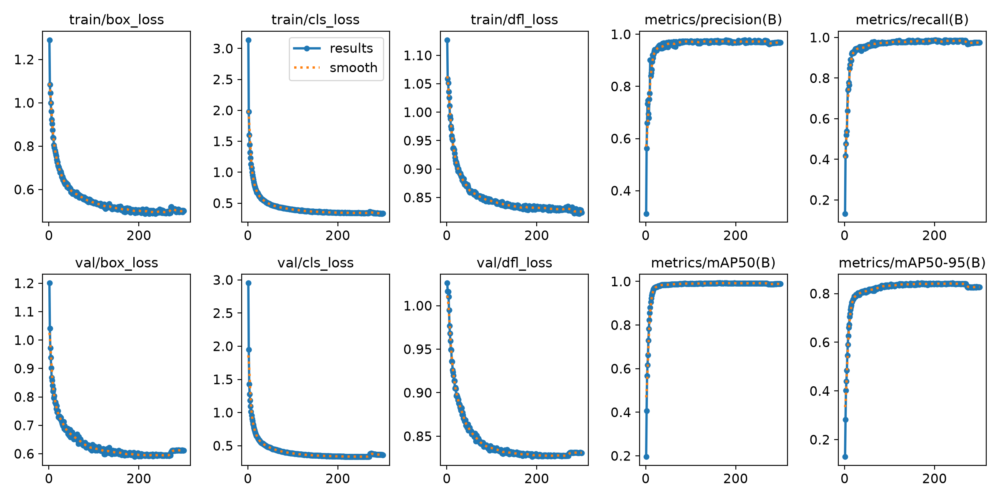

In [31]:
results_img = os.path.join(SAVE_PATH_DIGITS, EXPERIMENT_NAME_DIGITS, "results.png")
display.Image(filename=results_img)

No hay indicios de sobreajuste, sino que se ve una convergencia estable y sostenida. Las curvas de pérdida de validación y entrenamiento van disminuyendo mientras pasan las épocas. De forma análoga, las métricas van subiendo rápidamente durante las primeras 50 iteraciones para luego estabilizarse en valores óptimos y consistentes.

Debido al volumen de datos y la extensión del entrenamiento, el modelo logra asimilar la alta dificultad de los datos con el _mosaic_ activado durante las primeras etapas, el cual junta varias imágenes en una sola. Por consiguiente, cuando se desactiva en la época 270, no se observa un salto abrupto en las métricas, sino más bien un asentamiento final de los valores. Esta fase permite que el modelo afine sus pesos sobre imágenes individuales no distorsionadas, lo cual se evidencia visualmente en la mitigación de las leves fluctuaciones de la pérdida de caja en validación ('val/box_loss'), consolidando su capacidad de generalización.

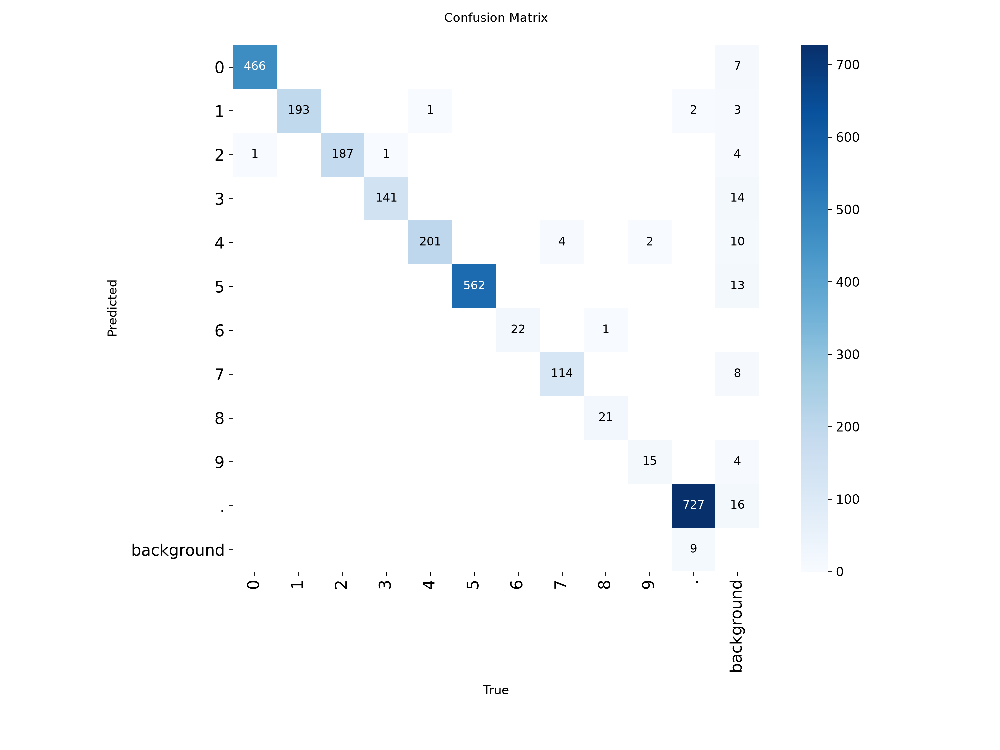

In [32]:
confusion_img = os.path.join(SAVE_PATH_DIGITS, EXPERIMENT_NAME_DIGITS, "confusion_matrix.png")
display.Image(filename=confusion_img)

Como se detalla en la matriz de confusión, la gran mayoría de los dígitos fueron detectados y clasificados correctamente por el modelo. Se observa una excelente precisión, ya que los errores de omisión o falsos negativos (instancias donde el modelo ignora un dígito y lo detecta como fondo) son inexistentes para los números y muy escasos para el separador decimal. Los pocos fallos que hubo entre clases son mínimos y atribuibles a ambigüedades propias de la escritura manual. No obstante, el separador decimal es la clase con el mayor índice de error, presentando confusiones con el fondo y ruido visual. Esto es esperado debido a las características del separador, pues ocupa una área muy reducida, lo que provoca que su detección sea más complicada en condiciones de iluminación subóptimas, desenfoque y resolución baja de la captura.

Los pesos del modelo final pueden ser descargados a través del siguiente enlace, desde el repositorio en Hugging Face: https://doi.org/10.57967/hf/10049.

## Evaluación final

Primero, se evalúa el modelo base (entrenado solo sobre SVHN) sobre el conjunto de prueba y se reporta su mejora relativa frente al modelo luego del _fine tuning_ sobre el conjunto de datos propio. La evaluación se realiza considerando las clases numéricas (dígitos del 0 al 9), debido a que SVHN no cuenta con la clase correspondiente al separador decimal.

In [33]:
# Evaluación del modelo base
MODEL_TEST_BASE = os.path.join(SAVE_PATH, EXPERIMENT_NAME, "weights", "best.pt")
VAL_NAME_BASE = "val_base_svhn"

!yolo val model="{MODEL_TEST_BASE}" data="{DATA_YAML}" \
    split=test imgsz={IMG_SIZE} conf=0.25 \
    classes=[0,1,2,3,4,5,6,7,8,9] \
    project="{SAVE_PATH_DIGITS}" name="{VAL_NAME_BASE}" \
    save=True

Ultralytics 8.4.120  Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
WARNING val: Slow image access detected (ping: 0.10.0 ms, read: 5.51.5 MB/s, size: 25.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/

val: Scanning C:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_reconocimiento\digits_yolo\data\labels\test... 86 images, 0 backgrounds, 0 corrupt: 36% ━━━━──────── 86/233 255.3it/s 0.1s<0.6s
val: Scanning C:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_reconocimiento\digits_yolo\data\labels\test... 172 images, 0 backgrounds, 0 corrupt: 73% ━━━━━━━━╸─── 172/233 434.4it/s 0.2s<0.1s
val: Scanning C:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_reconocimiento\digits_yolo\data\labels\test... 233 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 233/233 859.0i

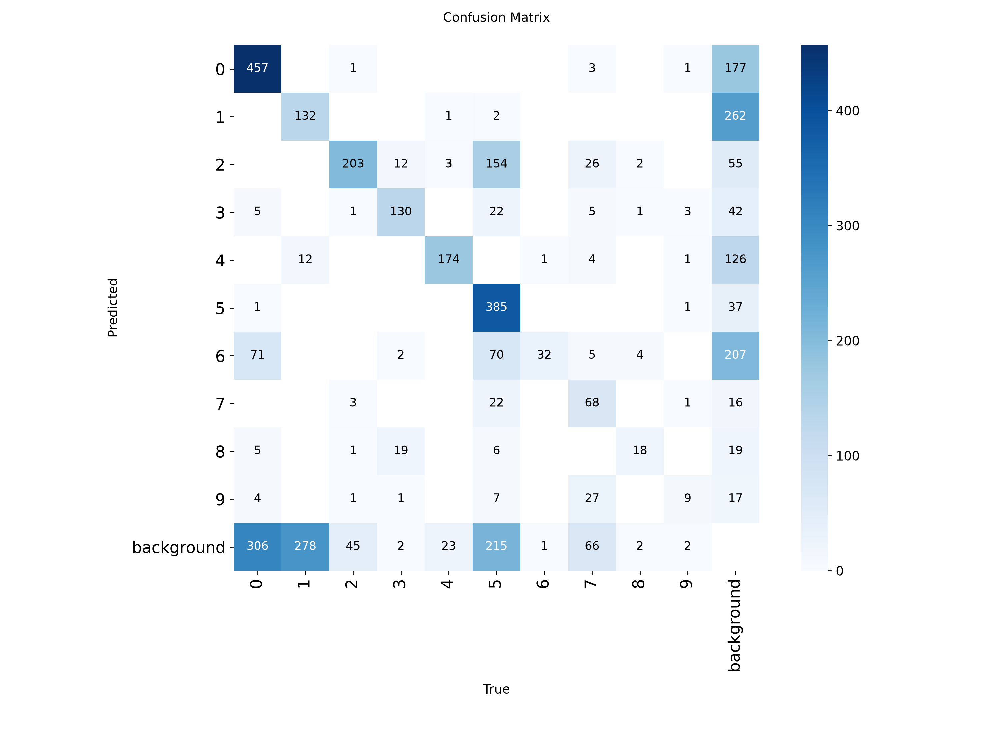

In [34]:
conf_img_base = os.path.join(SAVE_PATH_DIGITS, VAL_NAME_BASE, "confusion_matrix.png")
display.Image(filename=conf_img_base)

In [35]:
# Evaluación del modelo entrenado (multiclase)
# con las mismas clases (0 al 9) para una comparación directa
MODEL_TEST_MULTI_COMP = os.path.join(SAVE_PATH_DIGITS, EXPERIMENT_NAME_DIGITS, "weights", "best.pt")
VAL_NAME_MULTI_COMP = "val_multiclass_comp"

!yolo val model="{MODEL_TEST_MULTI_COMP}" data="{DATA_YAML}" \
    split=test imgsz={IMG_SIZE} conf=0.25 \
    classes=[0,1,2,3,4,5,6,7,8,9] \
    project="{SAVE_PATH_DIGITS}" name="{VAL_NAME_MULTI_COMP}" \
    save=True

Ultralytics 8.4.120  Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
Model summary (fused): 73 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 377.6142.5 MB/s, size: 21.5 KB)

val: Scanning C:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_reconocimiento\digits_yolo\data\labels\test.cache... 233 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 233/233  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 6% ╸─────────── 1/15 1.1it/s 0.3s<12.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 13% ━╸────────── 2/15 2.2it/s 0.5s<6.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 20% ━━────────── 3/15 3.1it/s 0.7s<3.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 26% ━━━───────── 4/15 3.8it/s 0.9s<2.9s
                 Class 

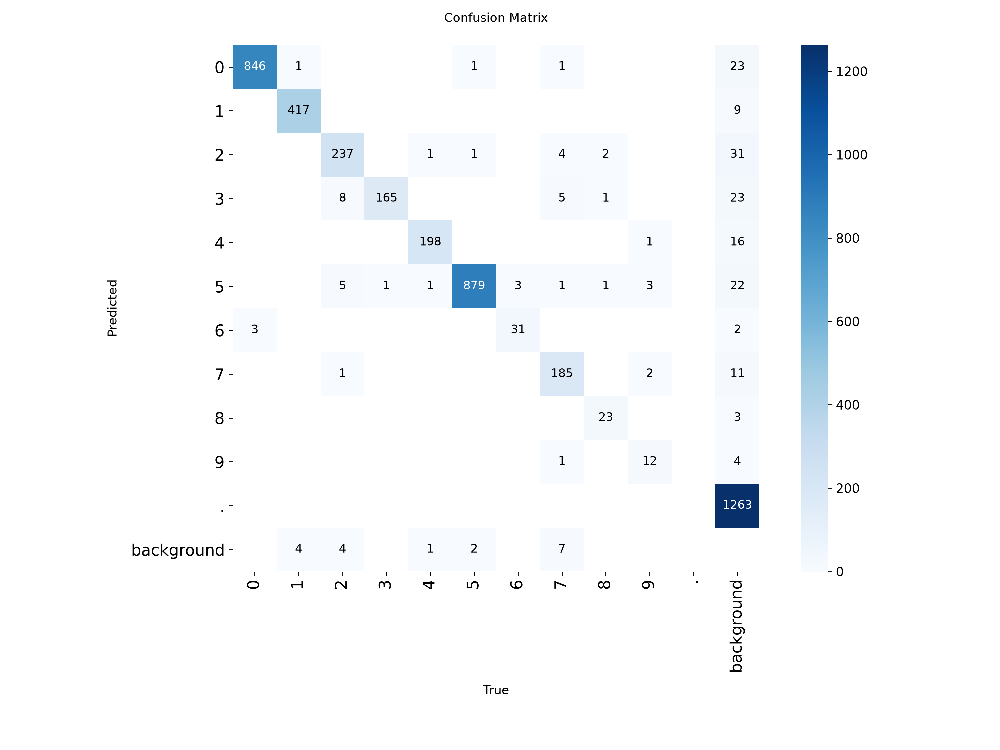

In [36]:
conf_img_multi_comp = os.path.join(SAVE_PATH_DIGITS, VAL_NAME_MULTI_COMP, "confusion_matrix.png")
display.Image(filename=conf_img_multi_comp)

Los resultados evidencian una brecha sustancial en el rendimiento de ambos modelos, destacando un incremento relativo del 233.06 % en la métrica más estricta (mAP50-95) a favor del modelo con el _fine tuning_ sobre el conjunto de datos propio. El modelo base (entrenado solo sobre SVHN) presentó deficiencias críticas para realizar predicciones en este contexto, logrando apenas un _recall_ de 0.552; esto significa que ignoró prácticamente la mitad de los dígitos presentes en las imágenes. Este bajo rendimiento se debe a un fuerte cambio de dominio, pues las características de los números presentes en placas de viviendas difieren radicalmente de los trazos manuscritos, la variabilidad en la caligrafía y ruido propio de las contracarátulas.

Después, se evalúa el modelo final sobre el conjunto de prueba (_data_ nunca antes vista por el modelo). La evaluación se realiza considerando, por un lado, la tarea de detección y clasificación (multiclase) y, por otro lado, solamente considerando como predicción buena si detecta la _bounding box_ (clase única).

In [37]:
# Evaluación del modelo entrenado (multiclase)
MODEL_TEST_MULTI = os.path.join(SAVE_PATH_DIGITS, EXPERIMENT_NAME_DIGITS, "weights", "best.pt")
VAL_NAME_MULTI = "val_multiclass"

!yolo val model="{MODEL_TEST_MULTI}" data="{DATA_YAML}" \
    split=test imgsz={IMG_SIZE} conf=0.25 \
    project="{SAVE_PATH_DIGITS}" name="{VAL_NAME_MULTI}" \
    save=True

Ultralytics 8.4.120  Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
Model summary (fused): 73 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 430.1139.3 MB/s, size: 26.8 KB)

val: Scanning C:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_reconocimiento\digits_yolo\data\labels\test.cache... 233 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 233/233  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 6% ╸─────────── 1/15 1.2it/s 0.2s<11.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 13% ━╸────────── 2/15 2.0it/s 0.5s<6.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 20% ━━────────── 3/15 2.7it/s 0.7s<4.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 26% ━━━───────── 4/15 3.5it/s 0.9s<3.2s
                 Class 

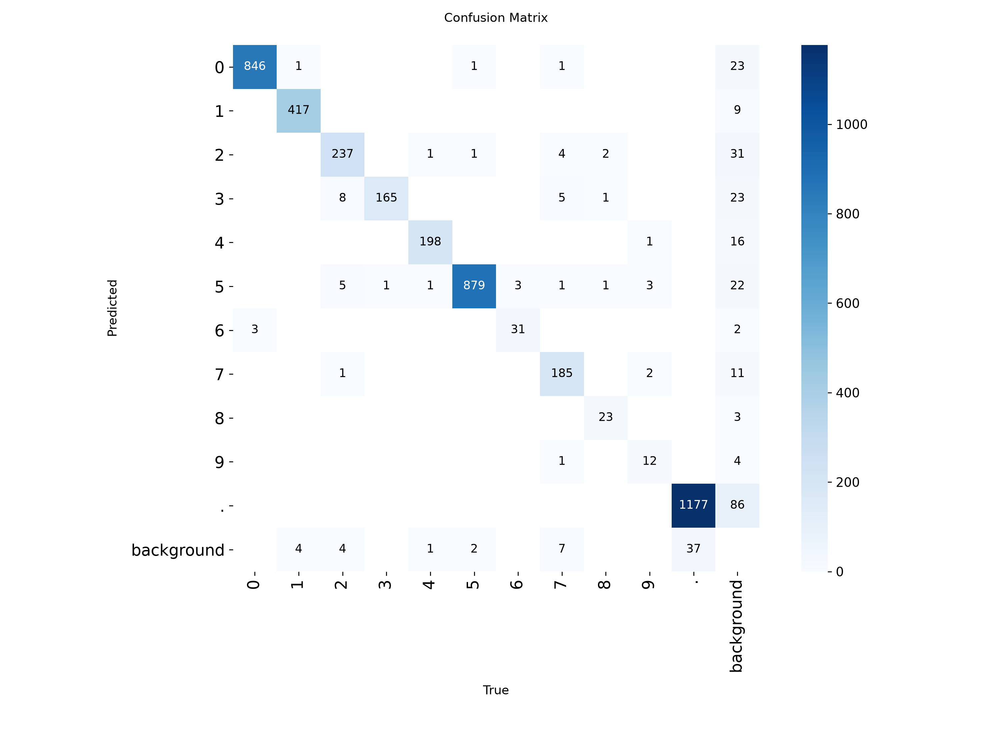

In [38]:
conf_img_multi = os.path.join(SAVE_PATH_DIGITS, VAL_NAME_MULTI, "confusion_matrix.png")
display.Image(filename=conf_img_multi)

Sobre el conjunto de prueba, el modelo logró un desempeño inferior en comparación con el conjunto de validación. Este comportamiento es acorde a lo esperado en un escenario de implementación real, dado que el conjunto de prueba introdujo condiciones visuales y contextuales de mayor complejidad. En la partición de datos, este conjunto incluyó una alta variabilidad de resoluciones. Además, se usó el video 19, el cual presentó una caligrafía particularmente compleja y ruido (anotaciones del jefe de práctica externas a la tabla principal), actuando como distractores. Aun con la presencia de estos elementos retadores, se lograron resultados muy buenos en las métricas (mAP50-95 de 0.813), por lo que se puede afirmar que el modelo generaliza ante datos con distintas características.

In [39]:
# Evaluación del modelo entrenado (clase única)
MODEL_TEST_SINGLE = os.path.join(SAVE_PATH_DIGITS, EXPERIMENT_NAME_DIGITS, "weights", "best.pt")
VAL_NAME_SINGLE = "val_singleclass"

!yolo val model="{MODEL_TEST_SINGLE}" data="{DATA_YAML}" \
    split=test imgsz={IMG_SIZE} conf=0.25 \
    project="{SAVE_PATH_DIGITS}" name="{VAL_NAME_SINGLE}" \
    save=True single_cls=True

Ultralytics 8.4.120  Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
Model summary (fused): 73 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 322.6106.0 MB/s, size: 20.2 KB)

val: Scanning C:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_reconocimiento\digits_yolo\data\labels\test.cache... 233 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 233/233  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 6% ╸─────────── 1/15 1.2s/it 0.4s<17.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 13% ━╸────────── 2/15 1.7it/s 0.6s<7.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 20% ━━────────── 3/15 2.3it/s 0.9s<5.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 26% ━━━───────── 4/15 2.9it/s 1.1s<3.8s
                 Class 

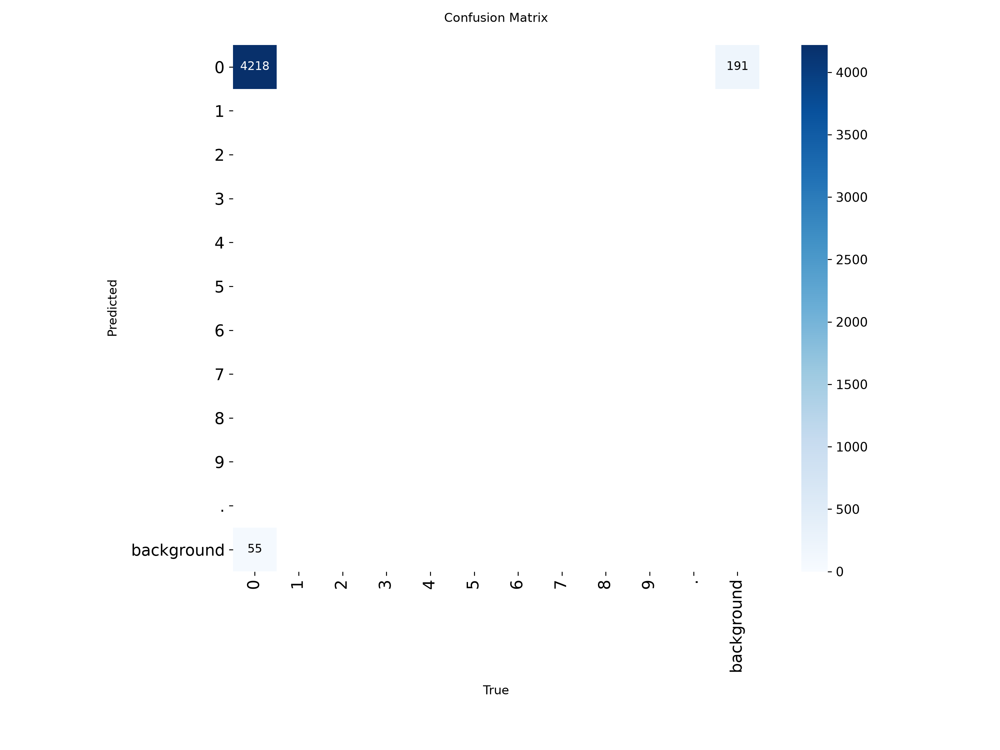

In [40]:
conf_img_single = os.path.join(SAVE_PATH_DIGITS, VAL_NAME_SINGLE, "confusion_matrix.png")
display.Image(filename=conf_img_single)

Considerando una única clase (tarea pura de detección), el modelo logró resultados superiores respecto a cuando considera todas las clases. El mAP50 presentó un aumento (+0.025), indicando una gran eficacia para localizar los caracteres de forma general. Destaca también el incremento del _recall_ y la precisión; esto sugiere que, al eliminar la penalización por los errores de clasificación entre dígitos específicos, el modelo es capaz de detectar una mayor cantidad de regiones de interés válidas. Asimismo, el mAP50-95 es ligeramente mayor (+0.014), confirmando que la exactitud de las _bounding boxes_ se mantiene robusta en umbrales de IoU que van desde 0.5 hasta 0.95.

En conclusión, la comparación demuestra que el modelo que predijo considerando una clase única obtiene un rendimiento general superior, destacando la mejora en el _recall_ y precisión. Esto evidencia que, si bien el modelo es muy eficaz localizando los caracteres, la predicción multiclase introduce penalizaciones debido a la alta variabilidad en la escritura de los dígitos, lo que dificulta la clasificación exacta de algunos que puedan ser ambiguos.

Al evaluar el desempeño multiclase, se observa que el mAP50-95, por lo general, no logra superar el umbral de 0.9 (excepto la clase '0', que llega a 0.936, y la '5', que llega a 0.902). Asimismo, hay algunas clases que presentan mayores retos: los dígitos '6', '7' y '9' tienen un peor rendimiento y el separador decimal mantiene un mAP50-95 inferior al resto de las clases por su reducida área. En consecuencia, dado el alto potencial del modelo para localizar las _bounding boxes_, se propone un _pipeline_ de dos etapas para poder realizar un mejor reconocimiento y clasificación de dígitos en contracarátulas: primero, el detector YOLO; segundo, un modelo especializado para manejar la tarea de clasificación de forma aislada.